In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler

torch.set_default_dtype(torch.float32)

LOAD DATASET

In [2]:
df=pd.read_csv('train.csv')
#9 inputs 19 outputs
X_train=np.array(df.iloc[:,:9])
y_train=np.array(df.iloc[:,9:])

df=pd.read_csv('test.csv')

X_test=np.array(df.iloc[:,:9])
y_test=np.array(df.iloc[:,9:])

names=df.columns

n_inputs=X_train.shape[1]
n_outputs=y_train.shape[1]

input_names=names[:9]
output_names=names[9:]

print(output_names)

Index(['Q1_MW', 'Q2_MW', 'T_reactor_out', 'X_CO', 'T3', 'P3', 'n3_total',
       'y_CO_3', 'y_H2_3', 'y_MeOH_3', 'y_H2O_3', 'P4', 'n4_total', 'x_CO_4',
       'x_H2_4', 'x_MeOH_4', 'x_H2O_4', 'MeOH_recovery',
       'MeOH_purity_stream4'],
      dtype='str')


PLOTTING

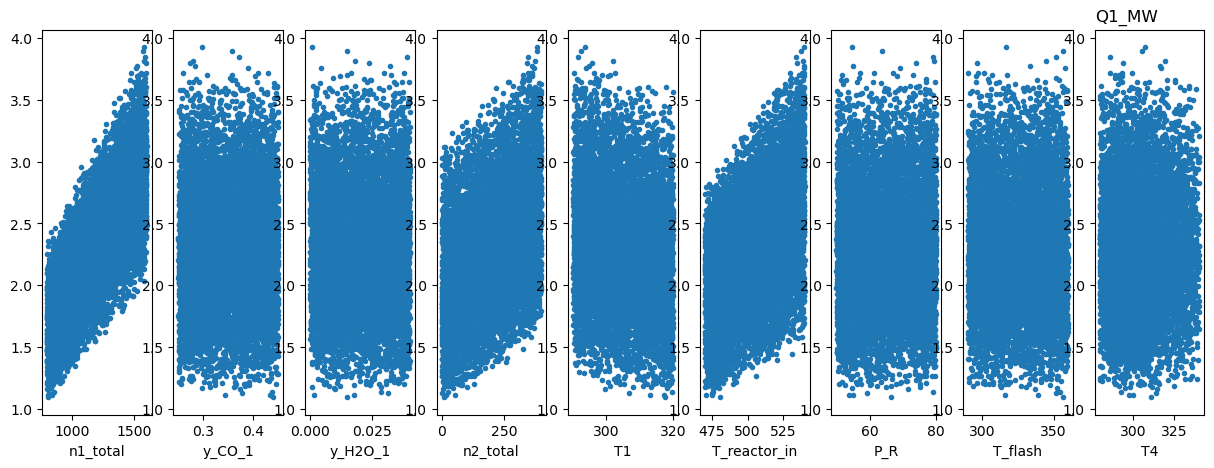

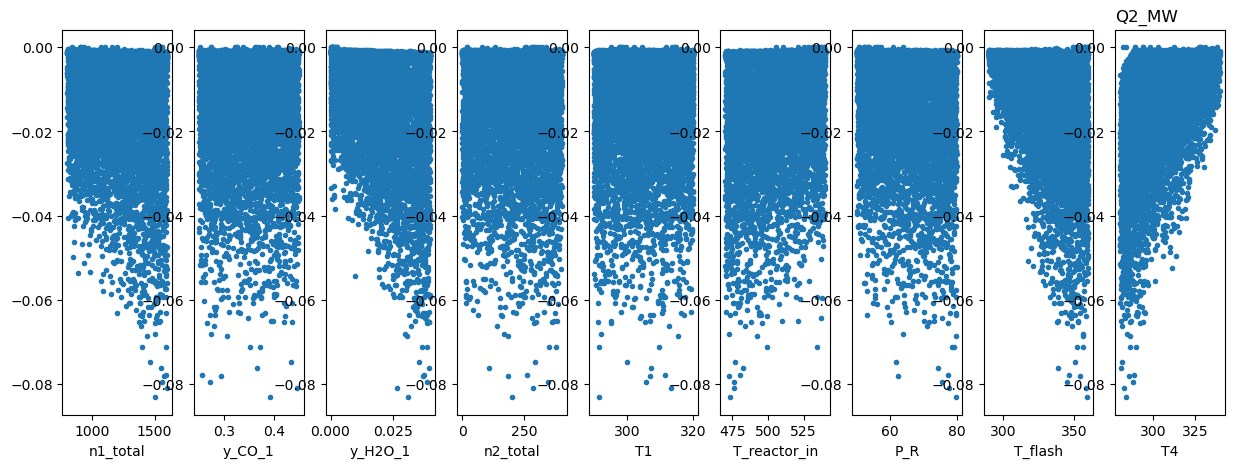

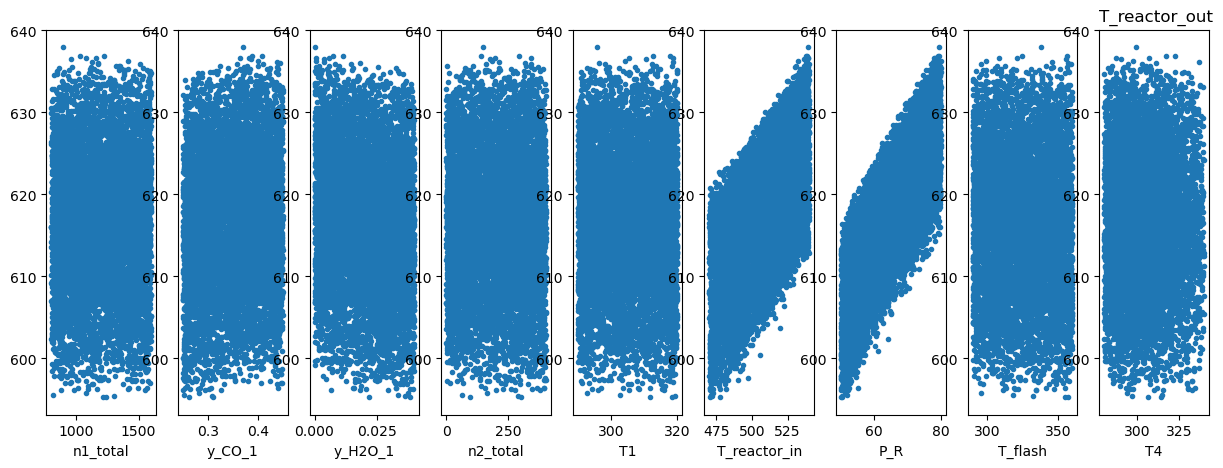

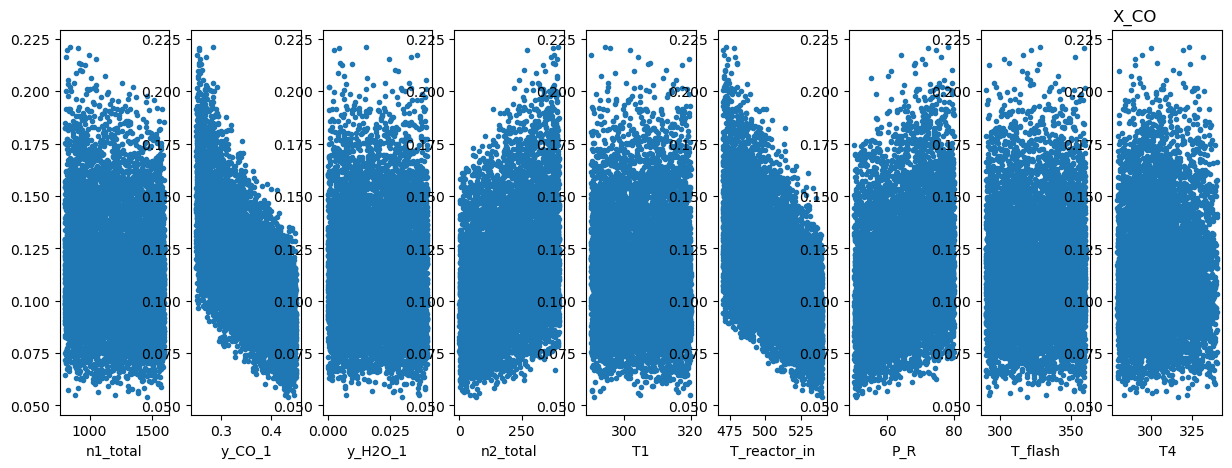

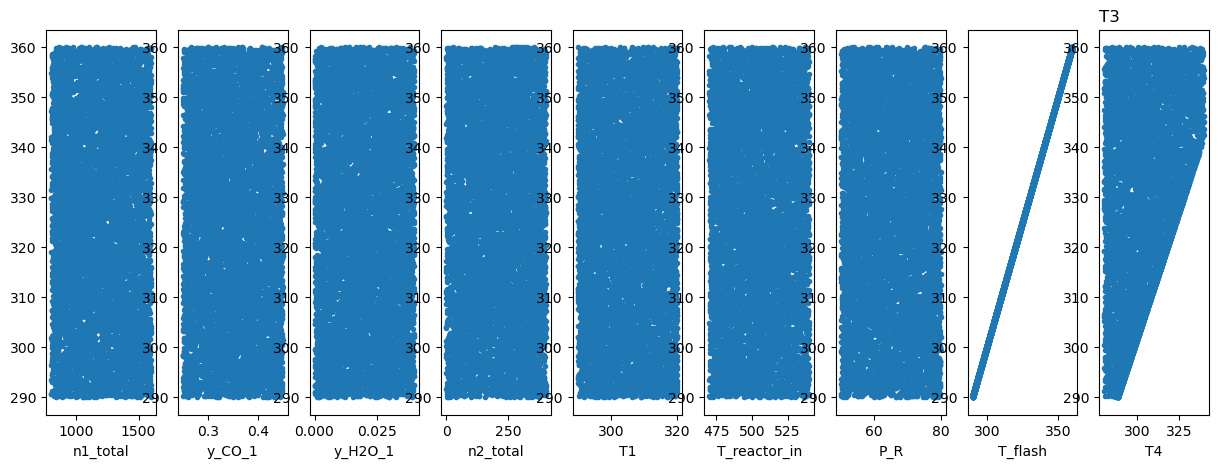

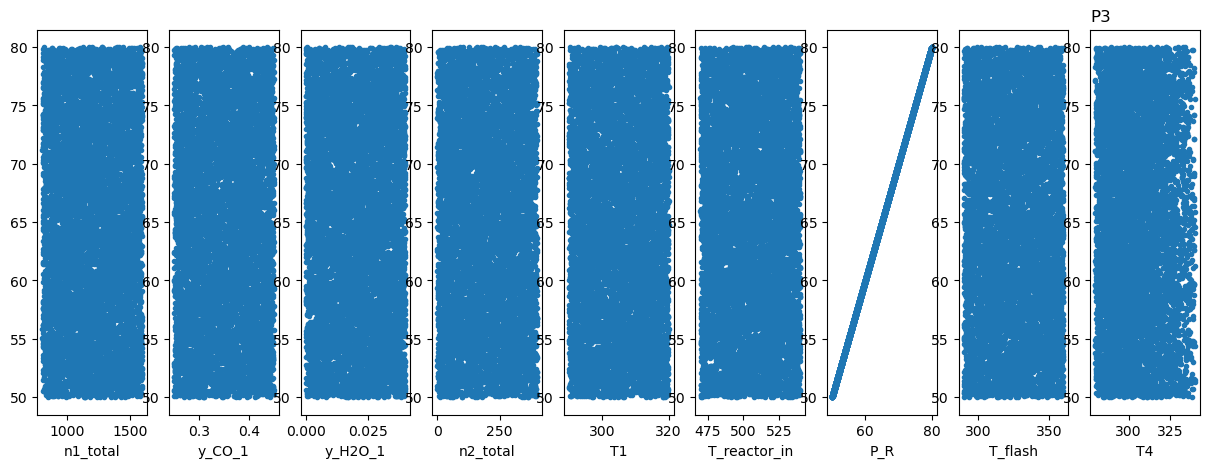

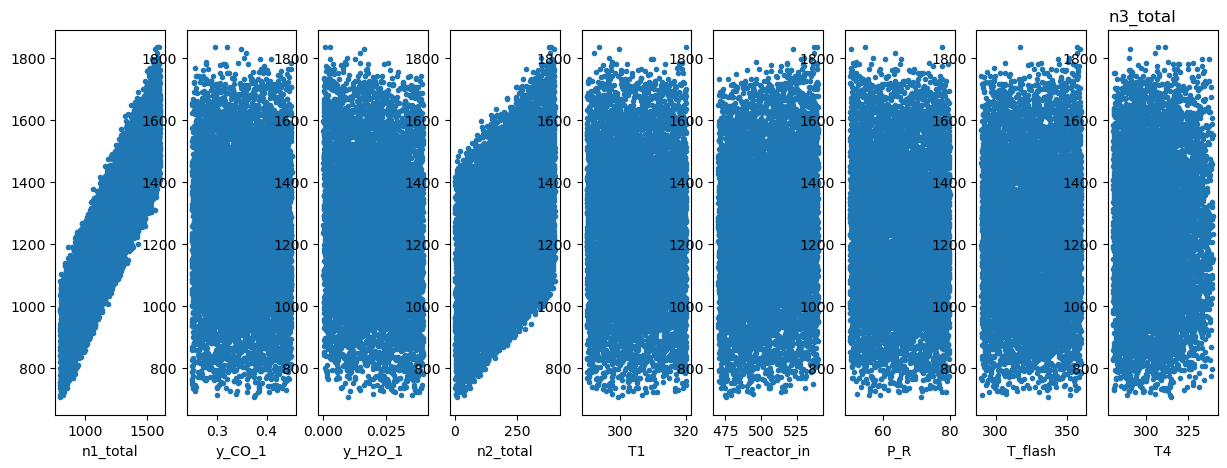

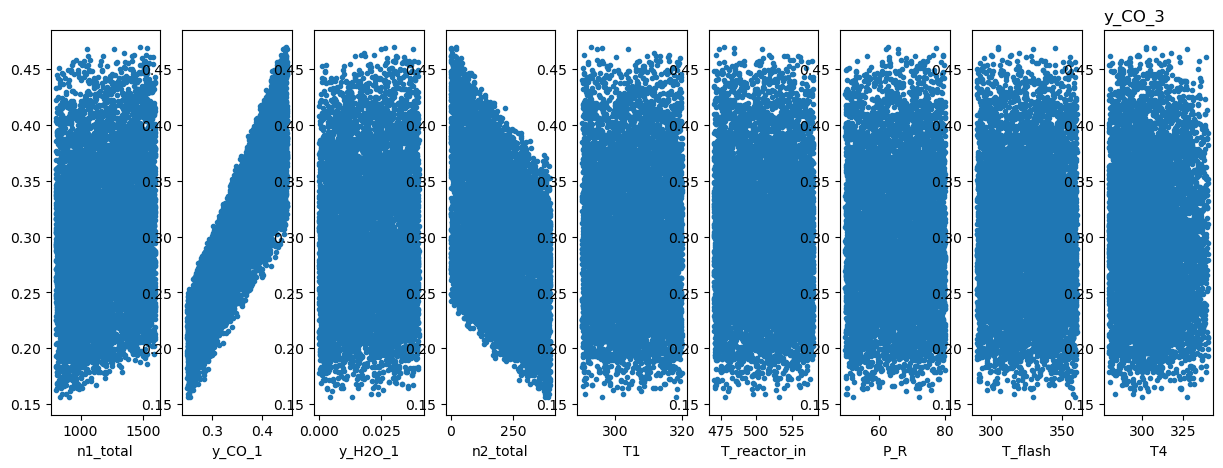

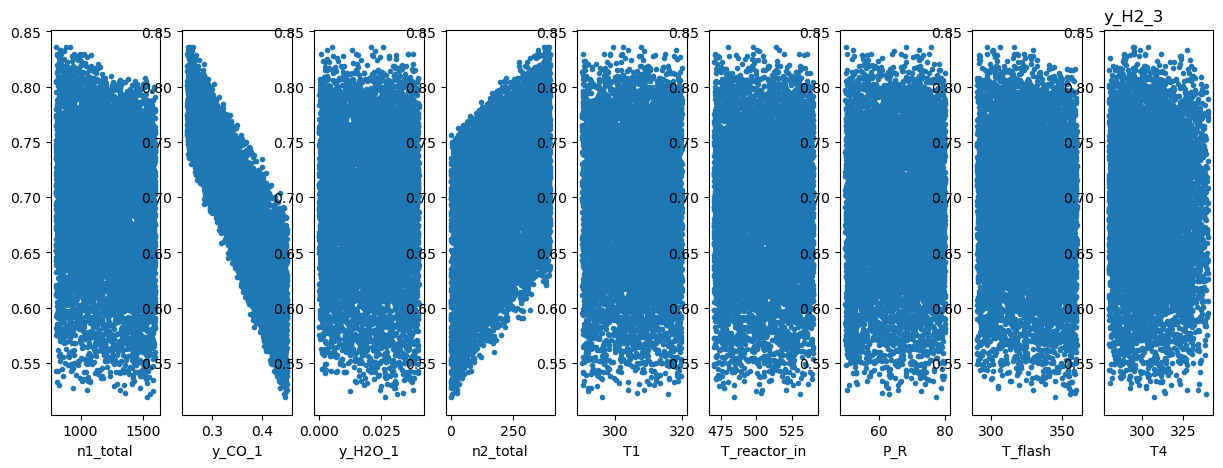

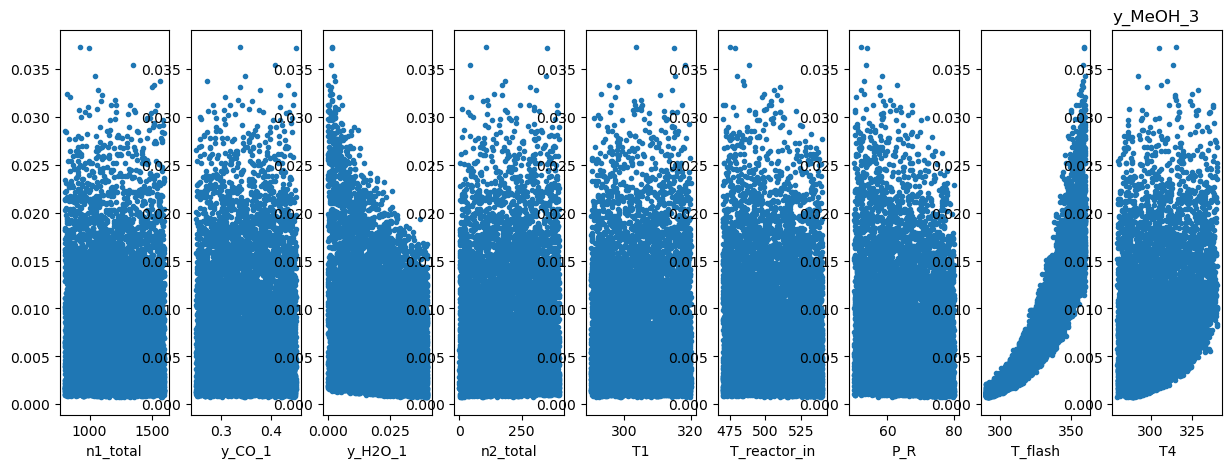

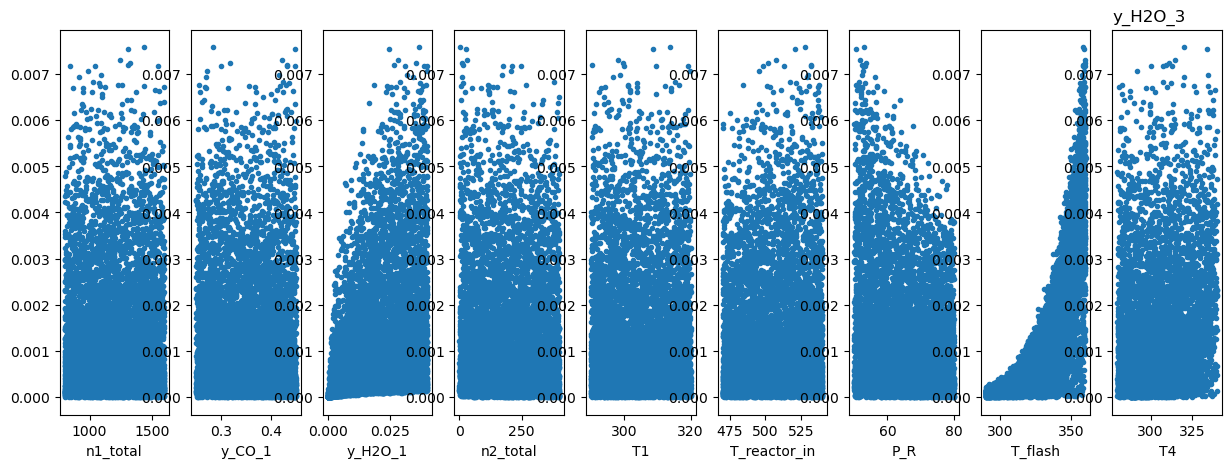

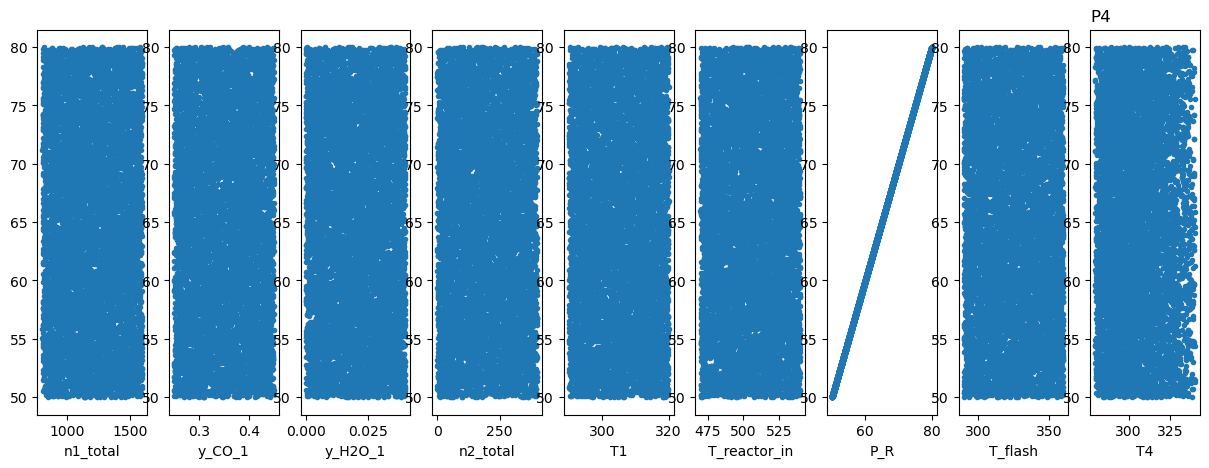

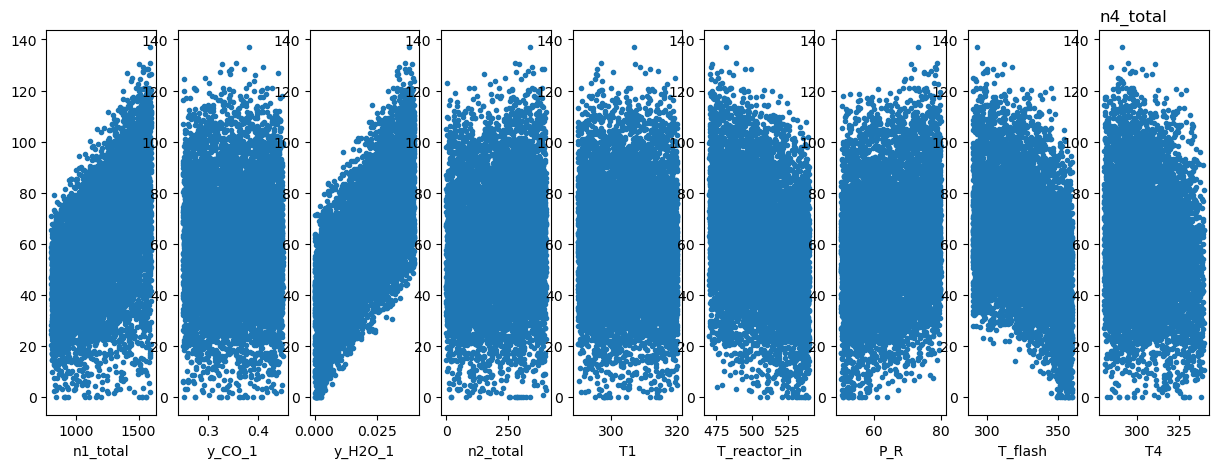

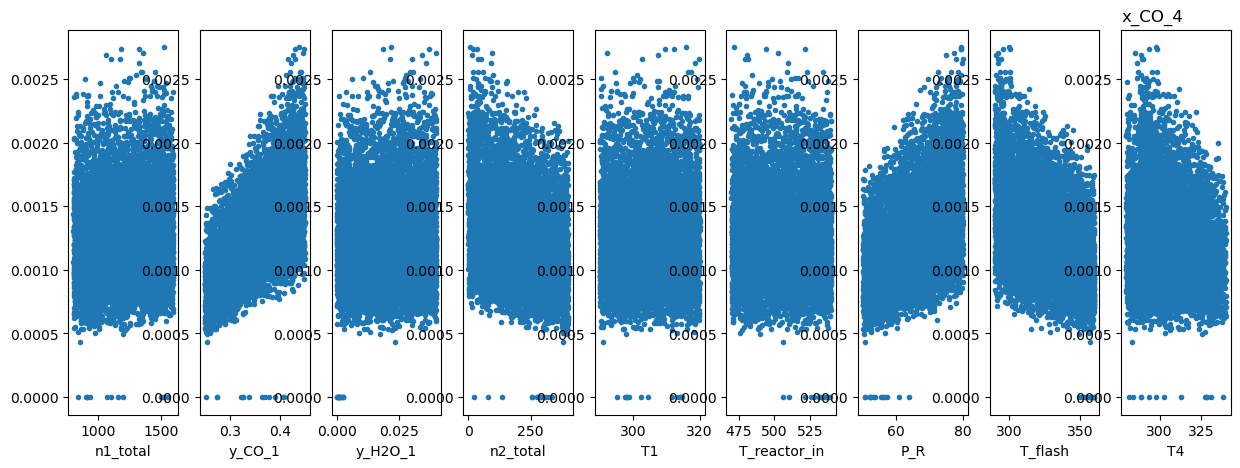

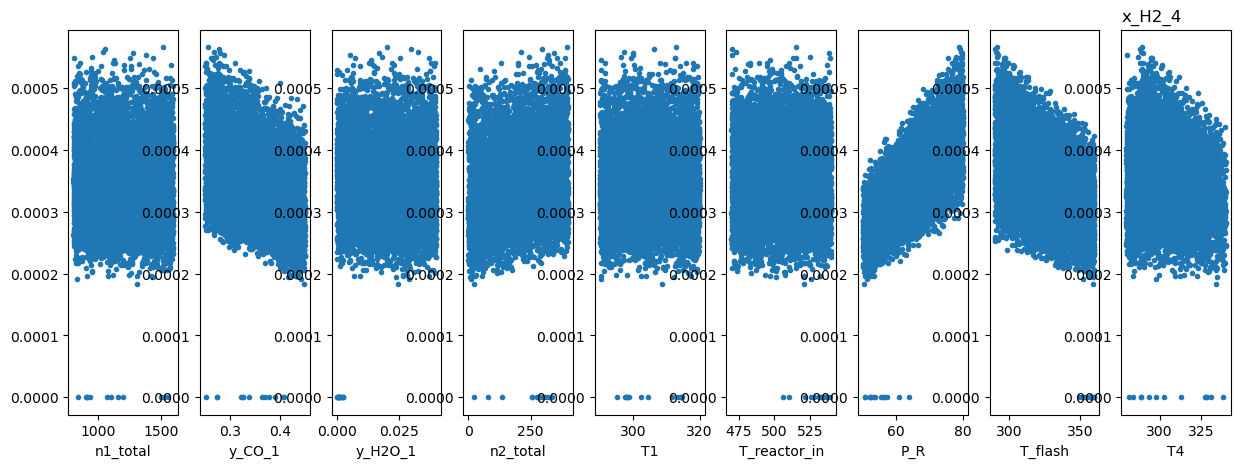

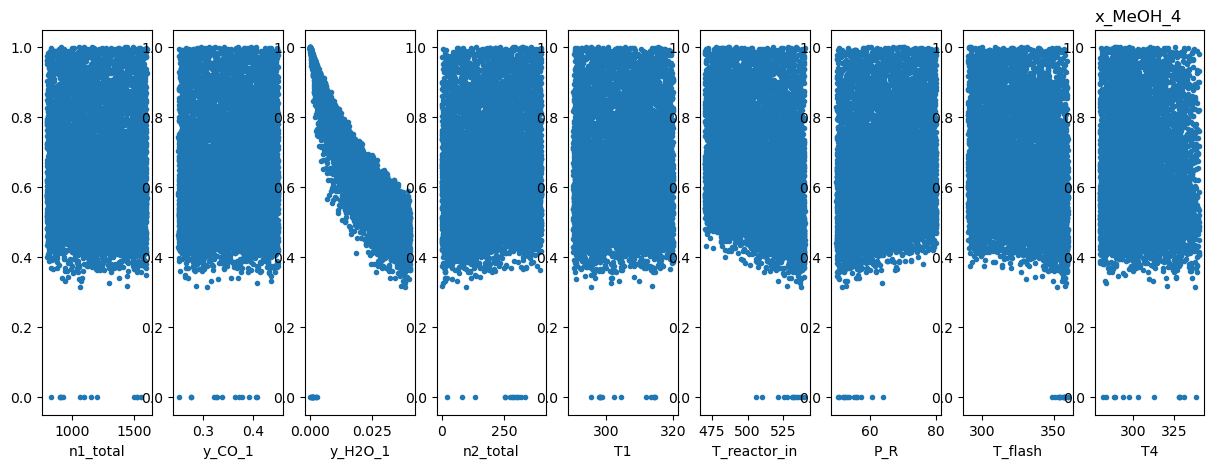

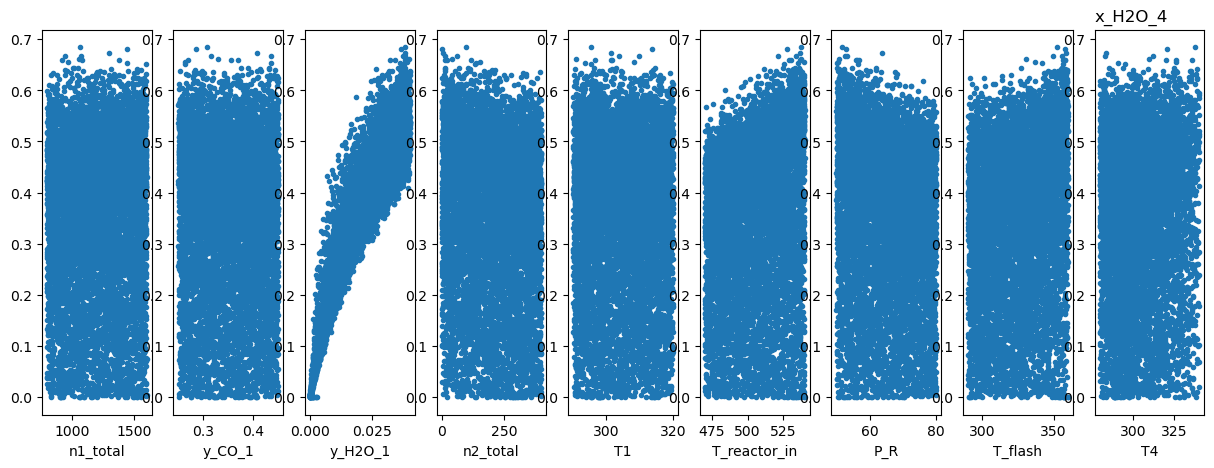

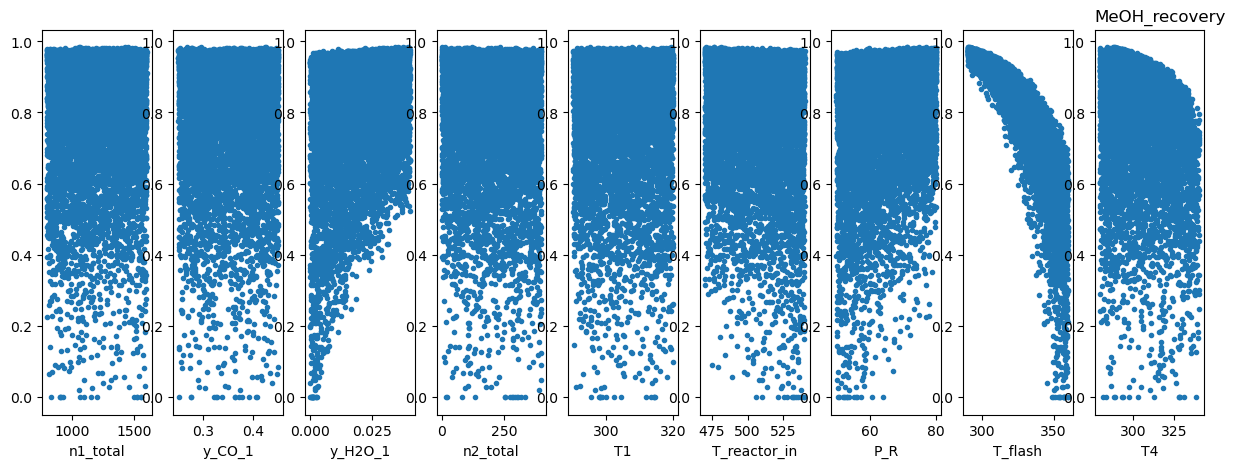

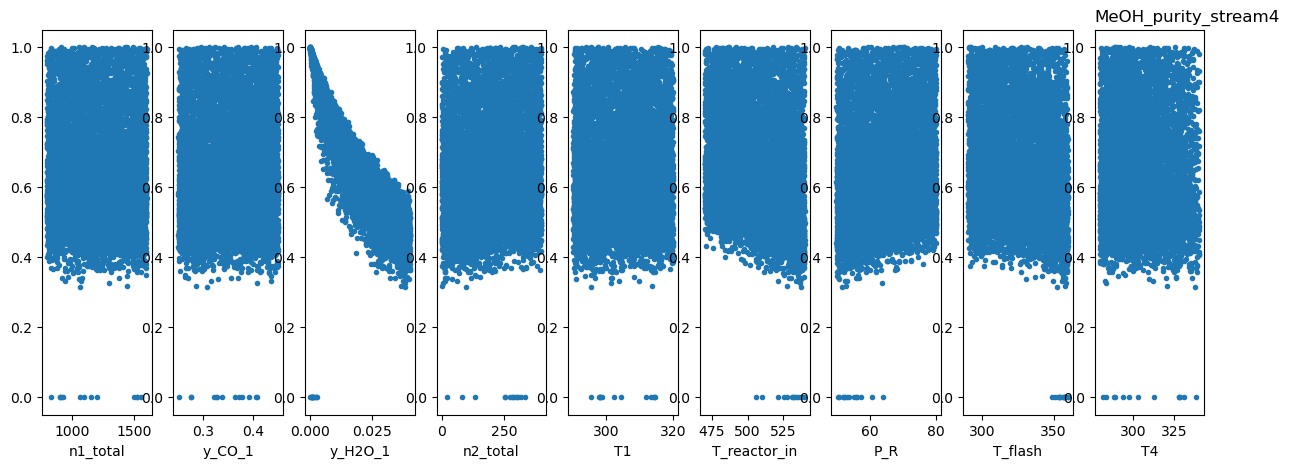

In [3]:
for i in range(y_train.shape[1]):  
    fig, ax= plt.subplots(1,X_train.shape[1],figsize=(15,5))
    plt.title(f'{output_names[i]}',loc='left')
    for j in range(X_train.shape[1]):
        ax[j].scatter(X_train[:,j],y_train[:,i],marker='.')
        ax[j].set_xlabel(input_names[j])

plt.show()

MULTILINEAR REGRESSION

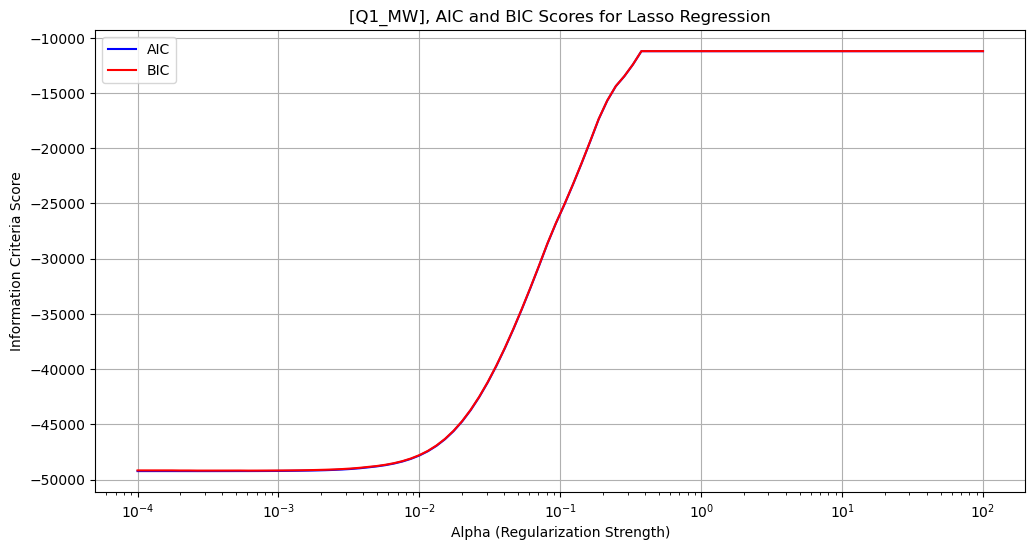

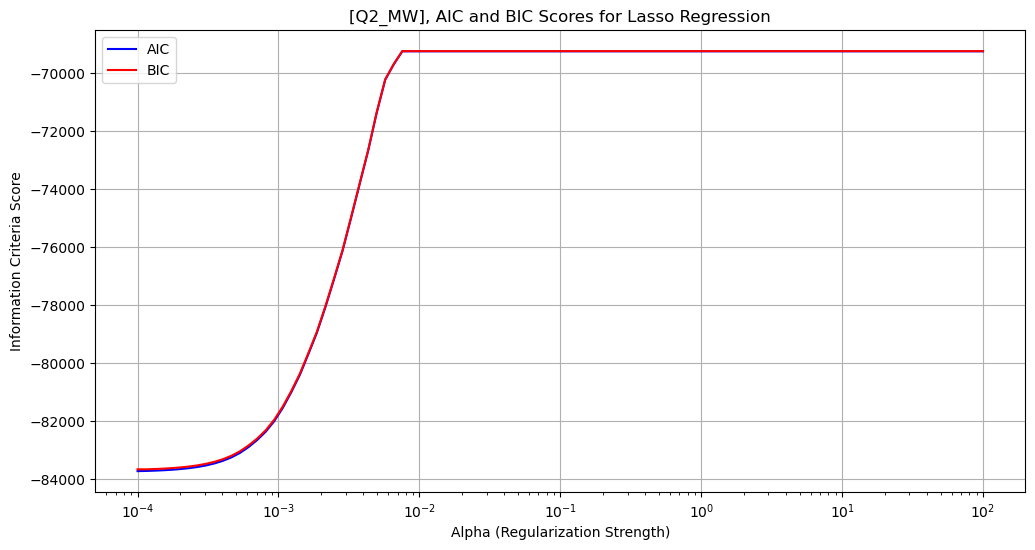

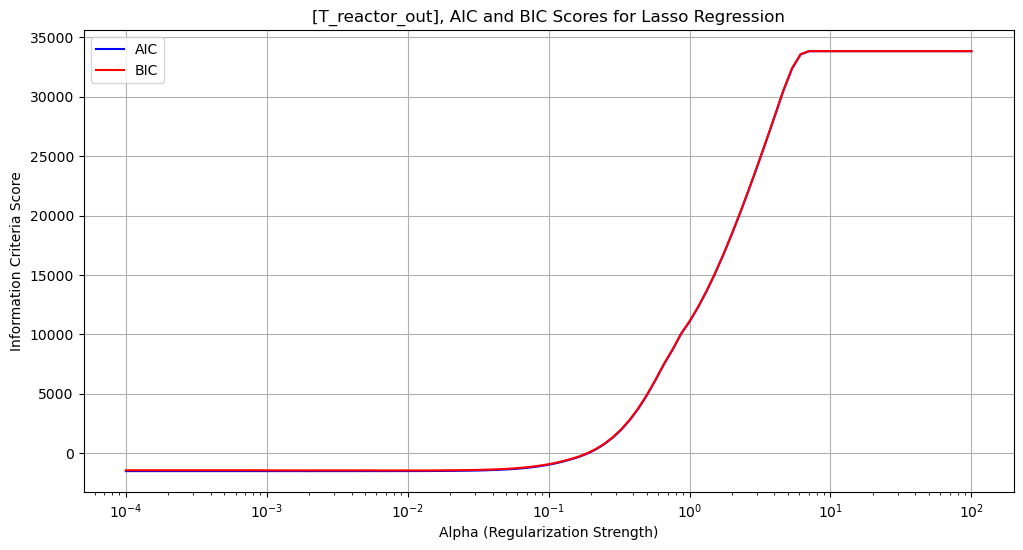

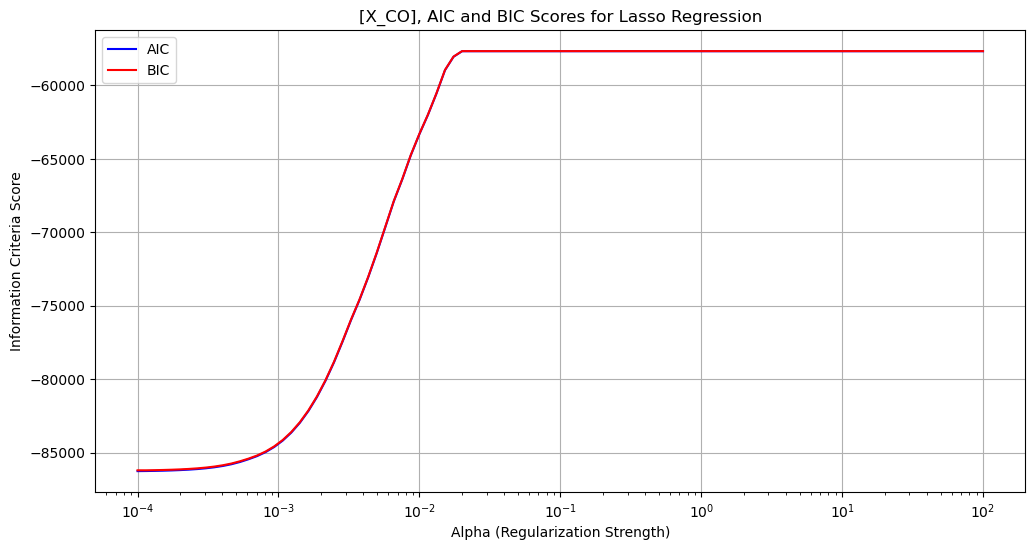

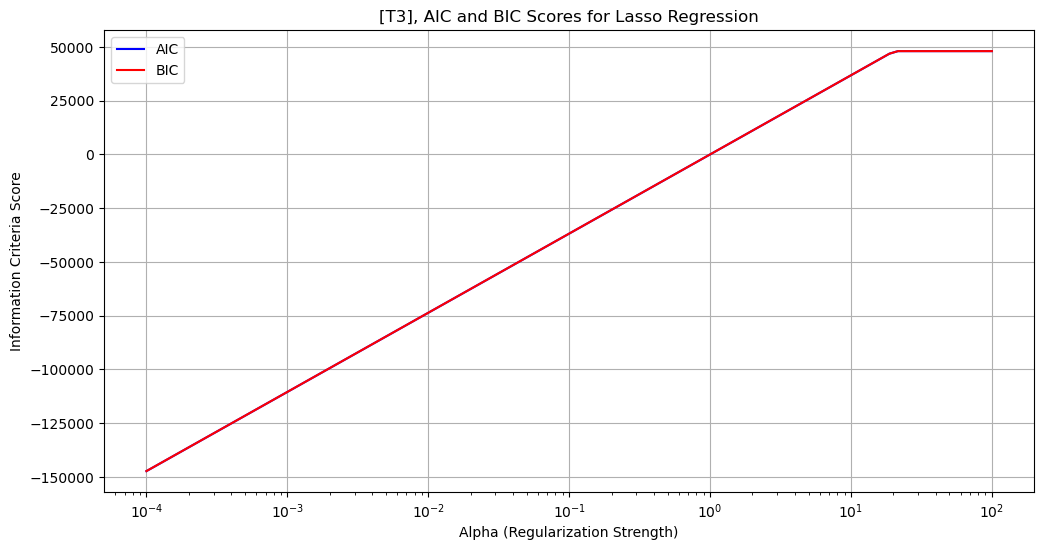

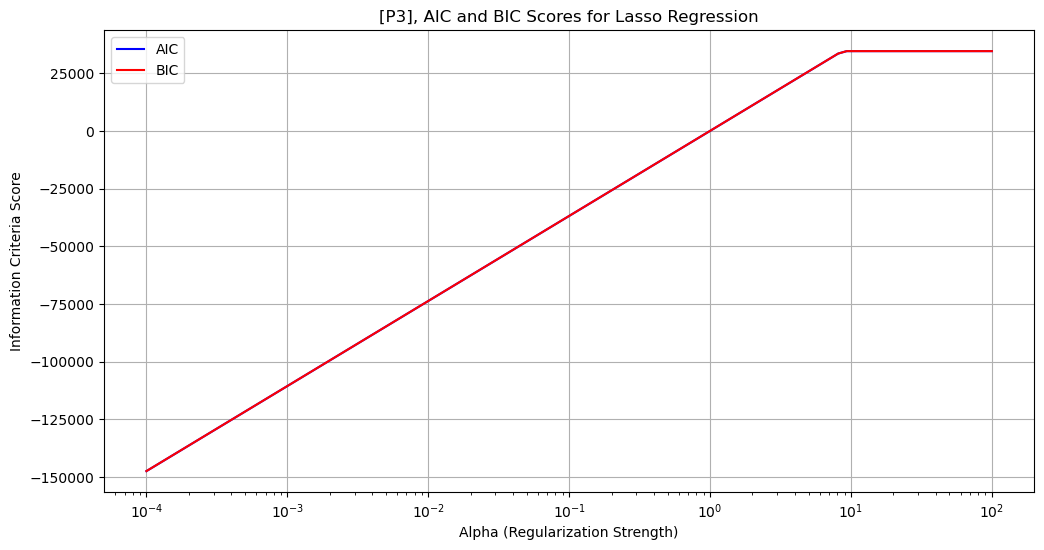

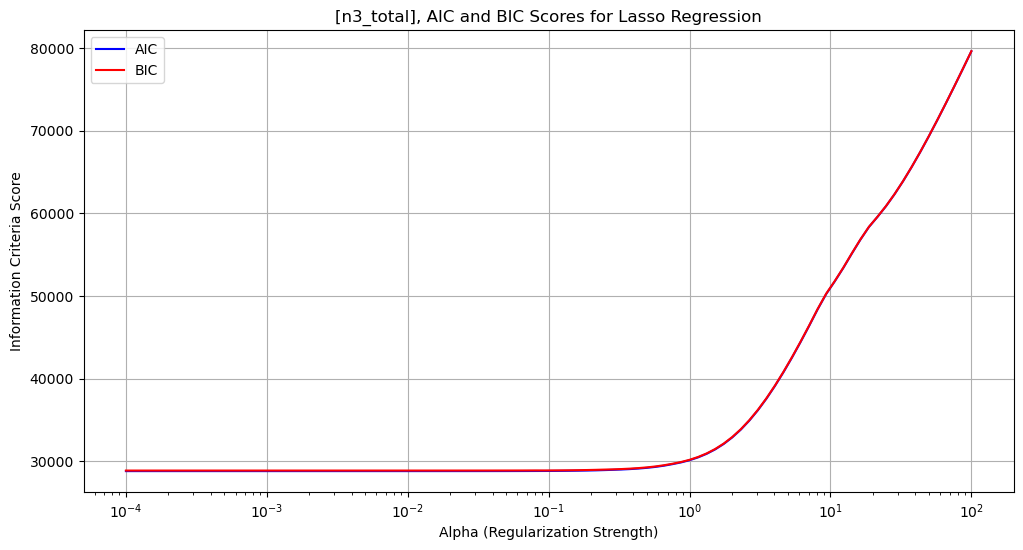

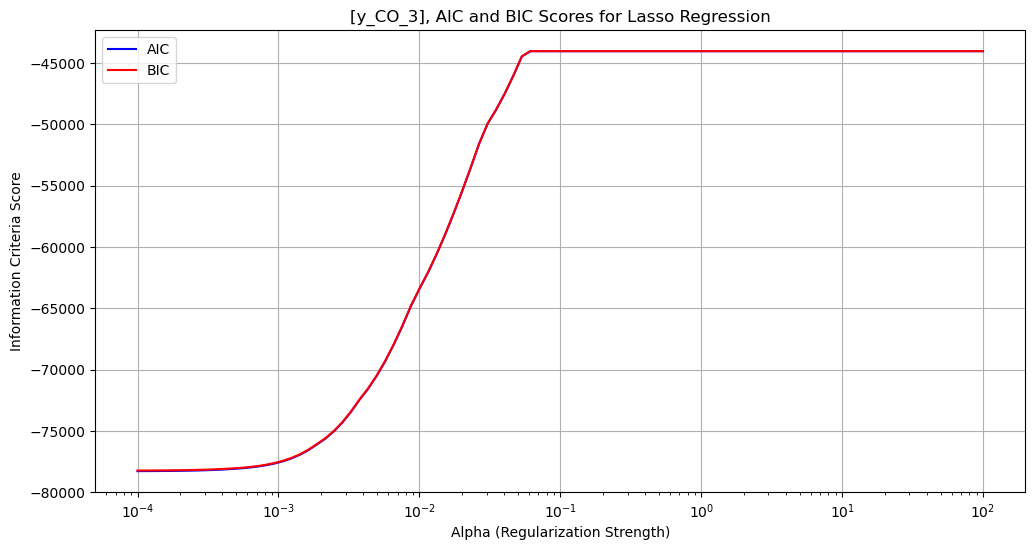

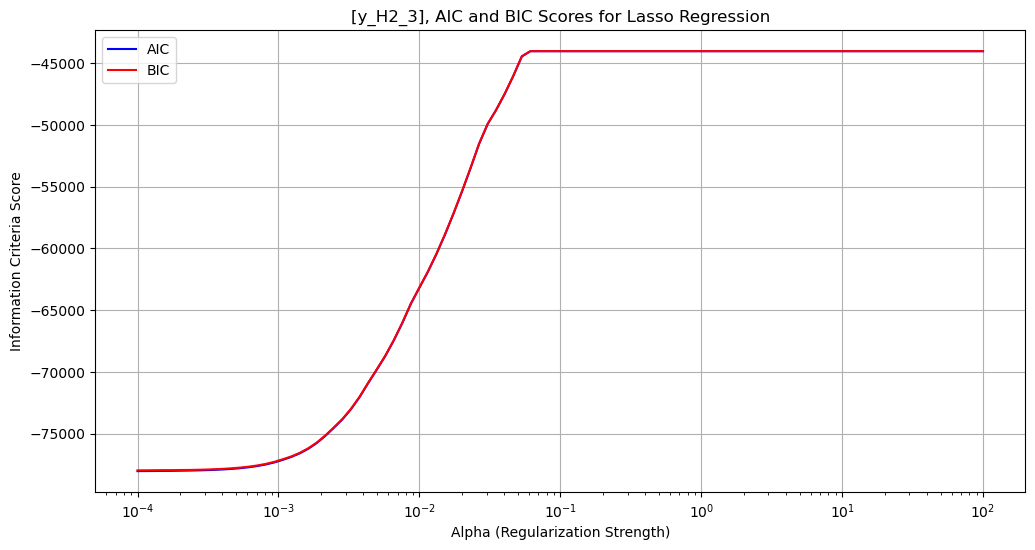

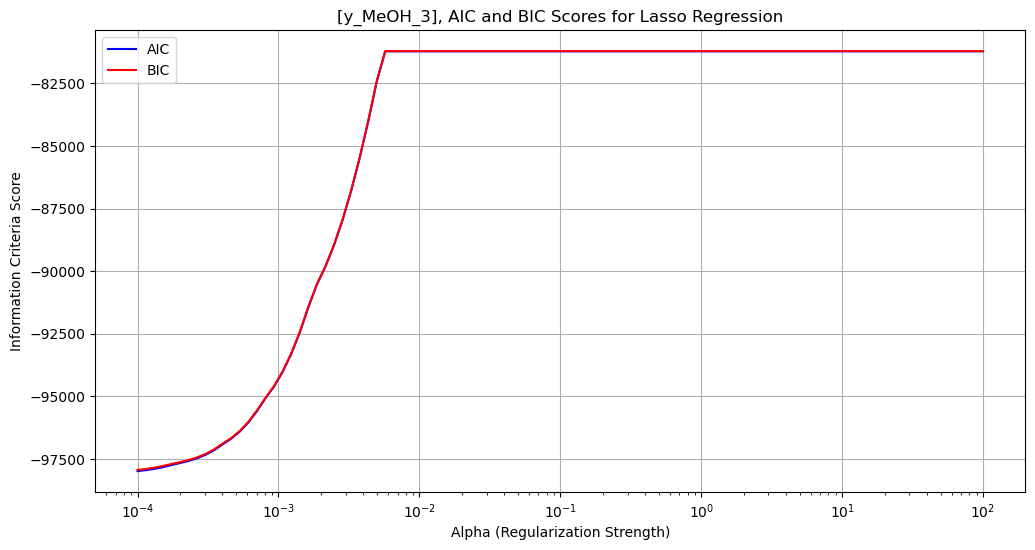

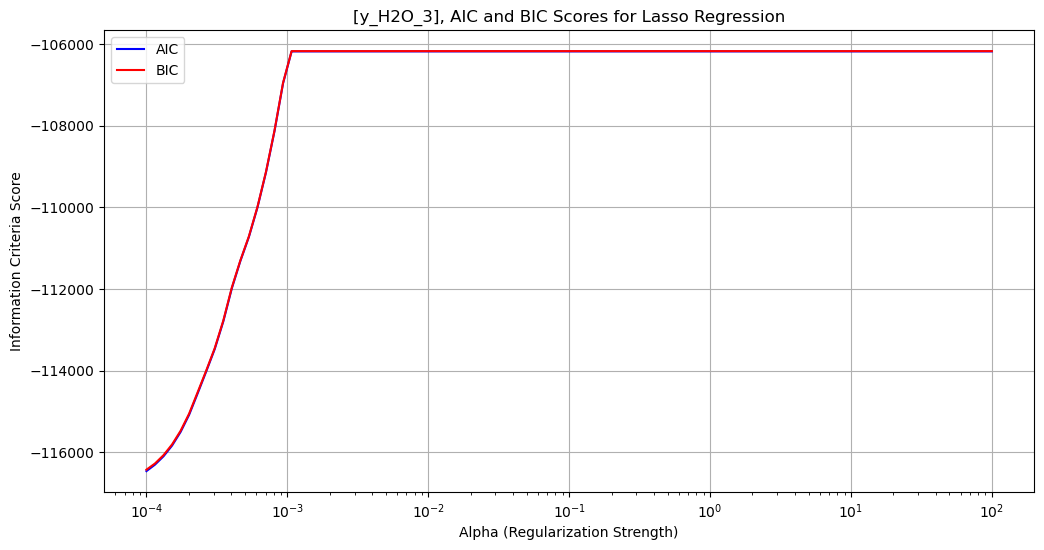

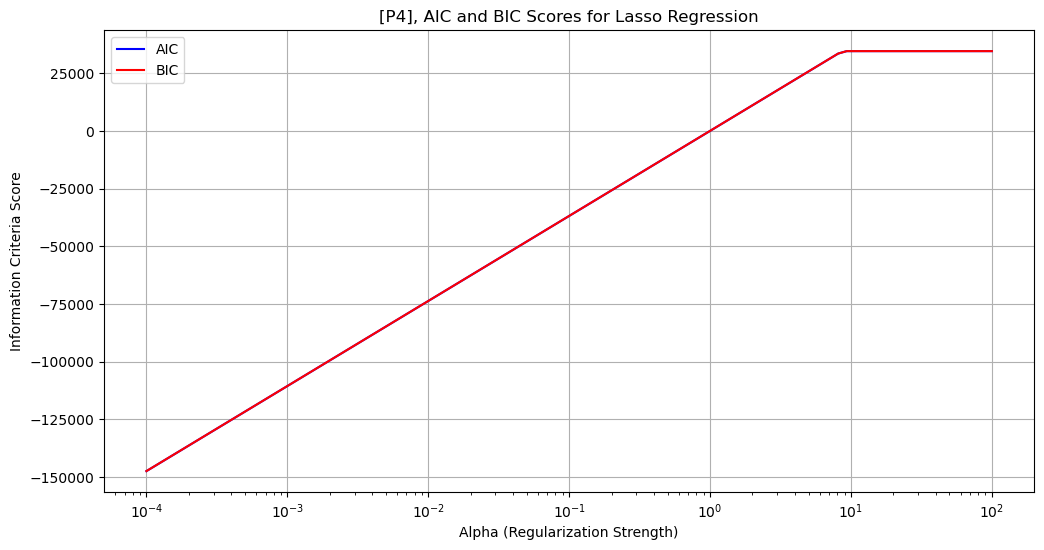

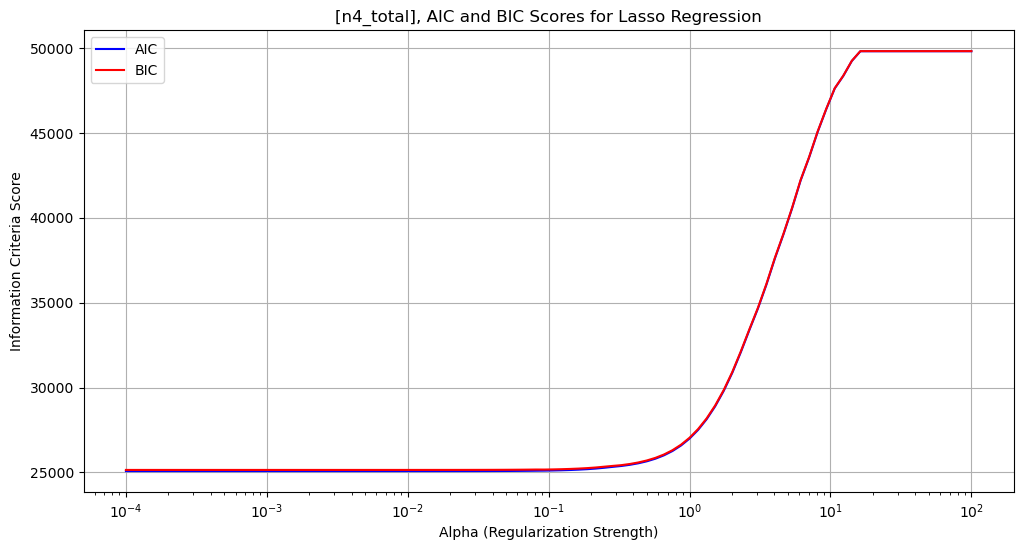

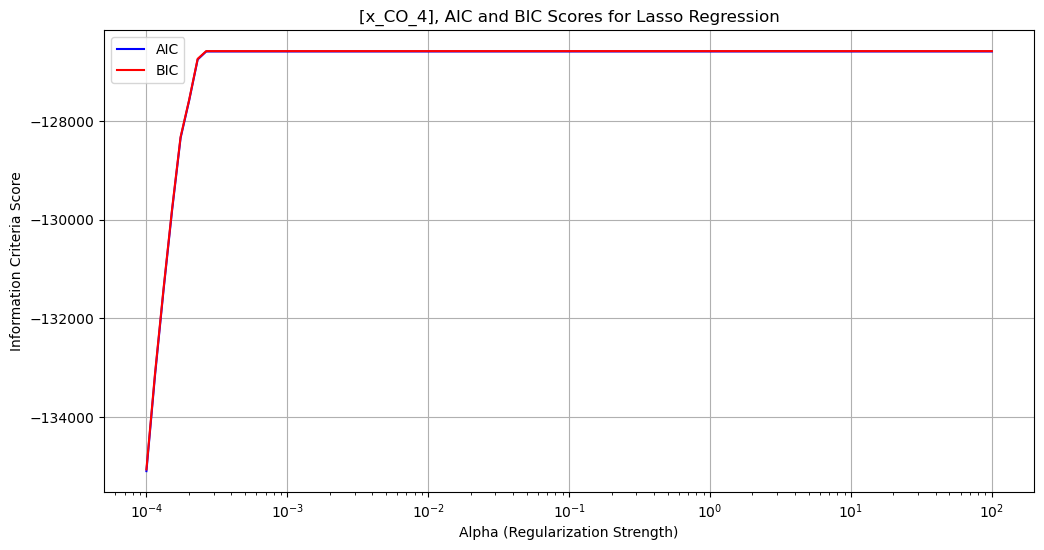

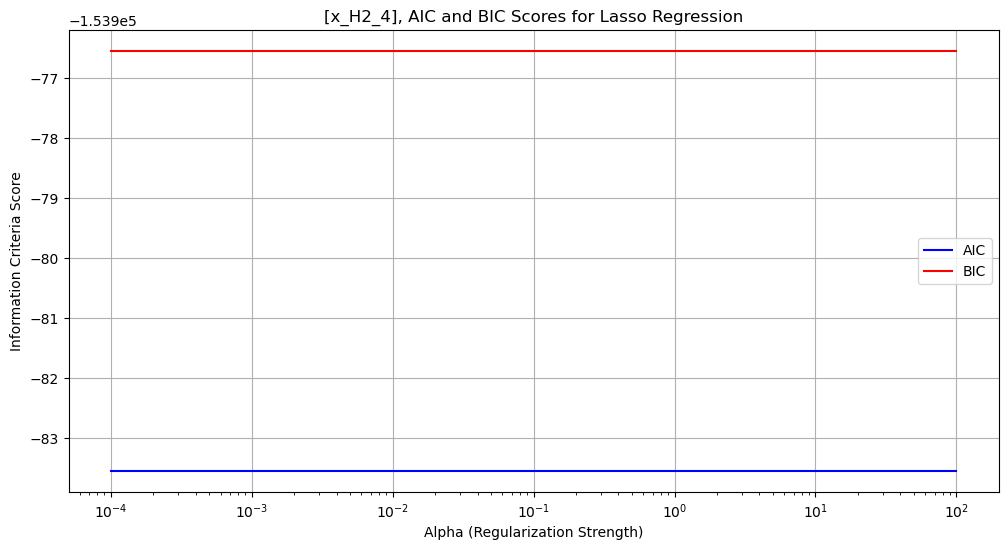

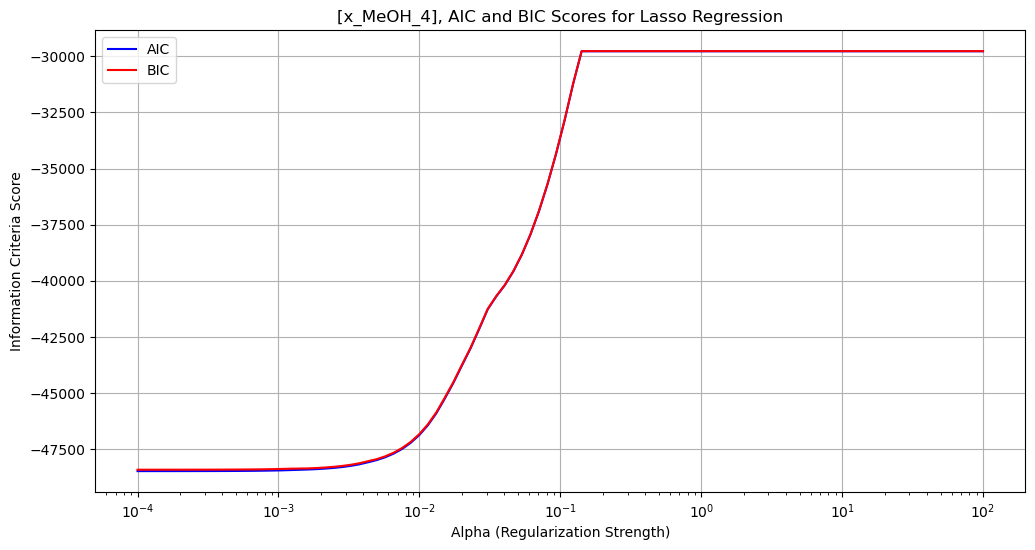

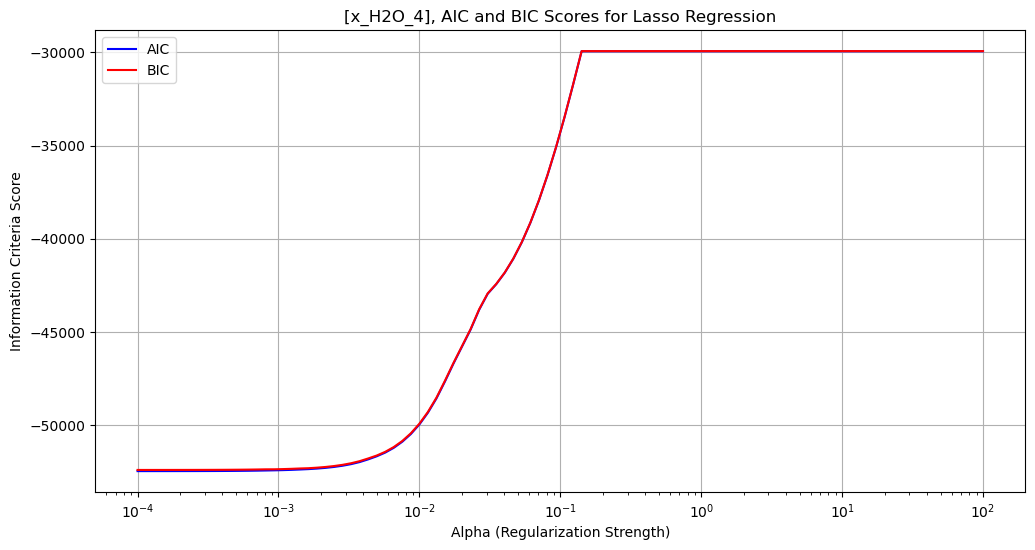

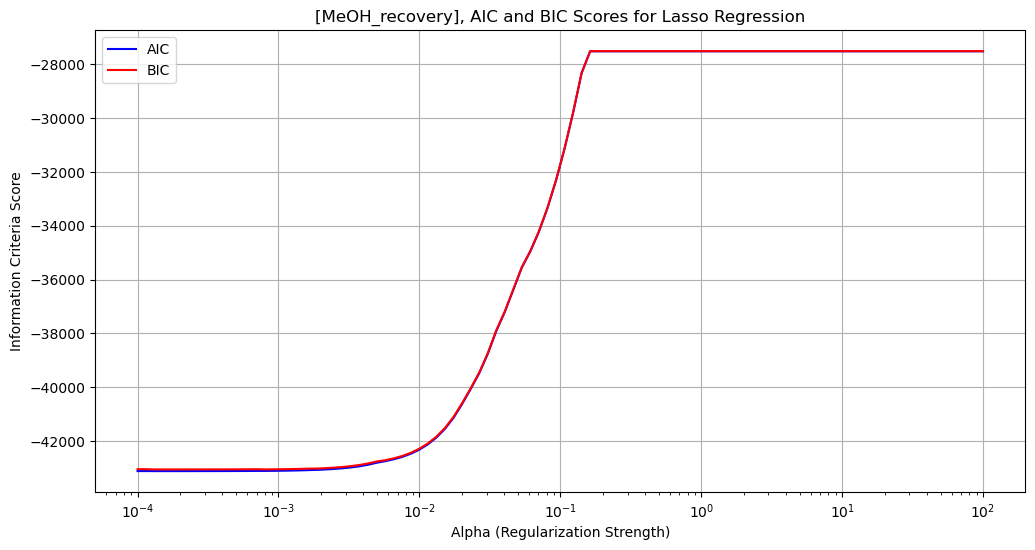

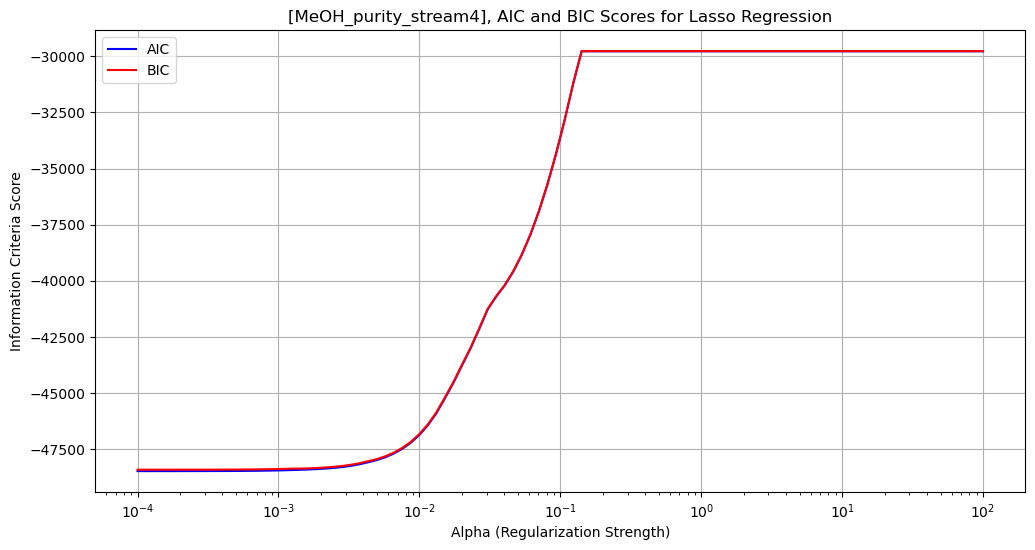

"\nalpha=1e-3\n\nlasso=Lasso(alpha=alpha)\nlasso.fit(X_train_n,y_train[:,0])\ncoefficients=lasso.coef_\nprint(coefficients)\ny_pred=lasso.predict(X_train_n)\n\n\n\nfig,ax =plt.subplots(1,2)\n\nax[0].scatter(y_train[:,0],y_pred,marker='.')\nax[0].set_xlabel('True Values')\nax[0].set_ylabel('Predicted Values')\nplt.show()\n"

In [4]:
X_avg=np.mean(X_train,axis=0)
X_std=np.std(X_train,axis=0)
X_train_n=(X_train-X_avg)/X_std

def AIC(y_true, y_pred, k):
    # AIC = n * log(RSS/n) + 2k
    n = len(y_true)
    rss = ((y_true - y_pred) ** 2).sum()
    return n * np.log(rss / n) + 2 * k

def BIC(y_true, y_pred, k):
    # BIC = n * log(RSS/n) + k * log(n)
    n = len(y_true)
    rss = ((y_true - y_pred) ** 2).sum()
    return n * np.log(rss / n) + k * np.log(n)


alphas = np.logspace(-4, 2, 100)
for i,output in enumerate(output_names):
    scores_aic = []
    scores_bic = []
    for alpha in alphas:
        lasso = Lasso(alpha=alpha)
        lasso.fit(X_train_n, y_train[:,i])
        y_pred = lasso.predict(X_train_n)
        k = np.sum(lasso.coef_ != 0) + 1  # non-zero features + intercept
        scores_aic.append(AIC(y_train[:,i], y_pred, k))
        scores_bic.append(BIC(y_train[:,i], y_pred, k))
        
    plt.figure(i,figsize=(12, 6))
    plt.plot(alphas, scores_aic, label='AIC', color='blue')
    plt.plot(alphas, scores_bic, label='BIC', color='red')
    #plt.plot(alphas, np.sqrt([scores_aic[j] * scores_bic[j] for j in range(len(alphas))]),
    #     label='Geometric Mean (AIC*BIC)^0.5', color='green')
    plt.xscale('log')
    plt.xlabel('Alpha (Regularization Strength)')
    plt.ylabel('Information Criteria Score')
    plt.title(f'[{output}], AIC and BIC Scores for Lasso Regression')
    plt.legend()
    plt.grid()
plt.show() 


'''
alpha=1e-3

lasso=Lasso(alpha=alpha)
lasso.fit(X_train_n,y_train[:,0])
coefficients=lasso.coef_
print(coefficients)
y_pred=lasso.predict(X_train_n)



fig,ax =plt.subplots(1,2)

ax[0].scatter(y_train[:,0],y_pred,marker='.')
ax[0].set_xlabel('True Values')
ax[0].set_ylabel('Predicted Values')
plt.show()
'''

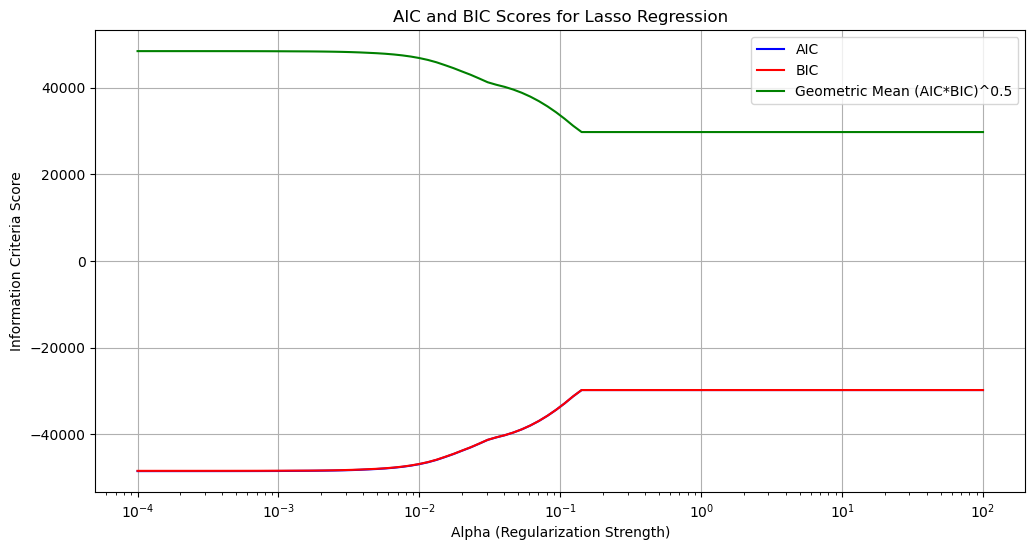

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(alphas, scores_aic, label='AIC', color='blue')
plt.plot(alphas, scores_bic, label='BIC', color='red')
plt.plot(alphas, np.sqrt([scores_aic[i] * scores_bic[i] for i in range(len(alphas))]),
         label='Geometric Mean (AIC*BIC)^0.5', color='green')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Information Criteria Score')
plt.title('AIC and BIC Scores for Lasso Regression')
plt.legend()
plt.grid()
plt.show()

NN TRAIN

NN CREATION

In [6]:
X_scaler=StandardScaler()
y_scaler=StandardScaler()

X_train_scaled=X_scaler.fit_transform(X_train)
X_test_scaled=X_scaler.transform(X_test)

y_train_scaled=y_scaler.fit_transform(y_train)
y_test_scaled=y_scaler.transform(y_test)

X_train_t=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_t=torch.tensor(y_train_scaled,dtype=torch.float32)

X_test_t=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_t=torch.tensor(y_test_scaled,dtype=torch.float32)

train_loader=DataLoader(TensorDataset(X_train_t,y_train_t), batch_size=32, shuffle=True)

In [7]:
net=nn.Sequential(
    nn.Linear(9,124),
    nn.Tanh(),
    nn.Linear(124,124),
    nn.Tanh(),
    nn.Linear(124,124),
    nn.Tanh(),
    nn.Linear(124,19),
)
criterion=nn.MSELoss()

optimizer=torch.optim.Adam(net.parameters())

In [8]:
n_epochs=50

net.train()

history_acc=[]
for epoch in range(n_epochs):
    correct=0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad() #We eliminate gradients to have the batches fully independent from each other
        #['Q1_MW', 'Q2_MW', 'T_reactor_out', 'X_CO', 'T3', 'P3', 'n3_total',
        #'y_CO_3', 'y_H2_3', 'y_MeOH_3', 'y_H2O_3', 'P4', 'n4_total', 'x_CO_4',
        #'x_H2_4', 'x_MeOH_4', 'x_H2O_4', 'MeOH_recovery',
        #'MeOH_purity_stream4'] 3,7,8,9,10,13,14,15,16,17
        raw_out = net(X_batch)

        out = raw_out.clone()
        '''
        # Single variables bounded between 0 and 1
        bounded_idx = [3, 17, 18]   # X_CO, MeOH_recovery, MeOH_purity_stream4
        out[:, bounded_idx] = torch.sigmoid(raw_out[:, bounded_idx])

        # Gas molar fractions: y_CO_3, y_H2_3, y_MeOH_3, y_H2O_3
        gas_frac_idx = [7, 8, 9, 10]
        out[:, gas_frac_idx] = F.softmax(raw_out[:, gas_frac_idx], dim=1)

        # Liquid molar fractions: x_CO_4, x_H2_4, x_MeOH_4, x_H2O_4
        liquid_frac_idx = [13, 14, 15, 16]
        out[:, liquid_frac_idx] = F.softmax(raw_out[:, liquid_frac_idx], dim=1)
        '''
        
        loss=criterion(out,y_batch) #We compute the loss for each batch

        loss.backward() #We back-propagate the loss 

        optimizer.step() #We use the optimizer's algorithm to change the weights based on the loss function 

        predicted=out.argmax(dim=1)
        #correct += (predicted==y_batch).sum().item()

In [ ]:
net.eval()

with torch.no_grad():
    model=net(X_train_t).numpy()
    model=y_scaler.inverse_transform(model)
# Single variables bounded between 0 and 1


'''

bounded_idx = [3, 17, 18]   # X_CO, MeOH_recovery, MeOH_purity_stream4
out[:, bounded_idx] = torch.sigmoid(model[:, bounded_idx])

# Gas molar fractions: y_CO_3, y_H2_3, y_MeOH_3, y_H2O_3
gas_frac_idx = [7, 8, 9, 10]
out[:, gas_frac_idx] = F.softmax(model[:, gas_frac_idx], dim=1)

# Liquid molar fractions: x_CO_4, x_H2_4, x_MeOH_4, x_H2O_4
liquid_frac_idx = [13, 14, 15, 16]
out[:, liquid_frac_idx] = F.softmax(model[:, liquid_frac_idx], dim=1)
'''
#mask=y_train !=0
#train_error=abs((model[mask]-y_train[mask])/y_train[mask])*100
#print(train_error.shape)
ì   

'\n\nbounded_idx = [3, 17, 18]   # X_CO, MeOH_recovery, MeOH_purity_stream4\nout[:, bounded_idx] = torch.sigmoid(model[:, bounded_idx])\n\n# Gas molar fractions: y_CO_3, y_H2_3, y_MeOH_3, y_H2O_3\ngas_frac_idx = [7, 8, 9, 10]\nout[:, gas_frac_idx] = F.softmax(model[:, gas_frac_idx], dim=1)\n\n# Liquid molar fractions: x_CO_4, x_H2_4, x_MeOH_4, x_H2O_4\nliquid_frac_idx = [13, 14, 15, 16]\nout[:, liquid_frac_idx] = F.softmax(model[:, liquid_frac_idx], dim=1)\n'

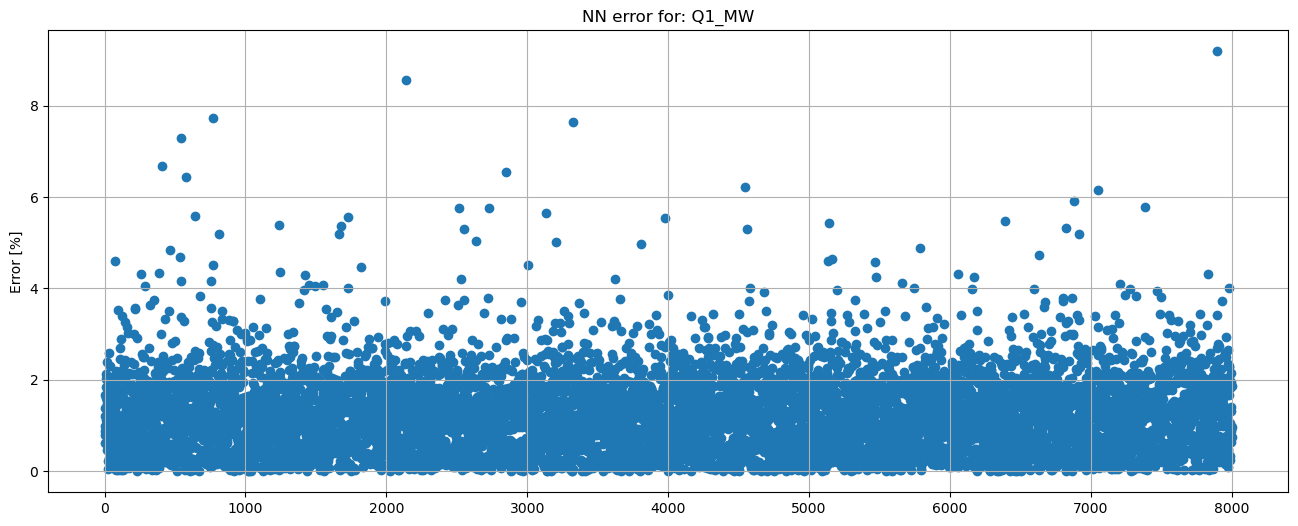

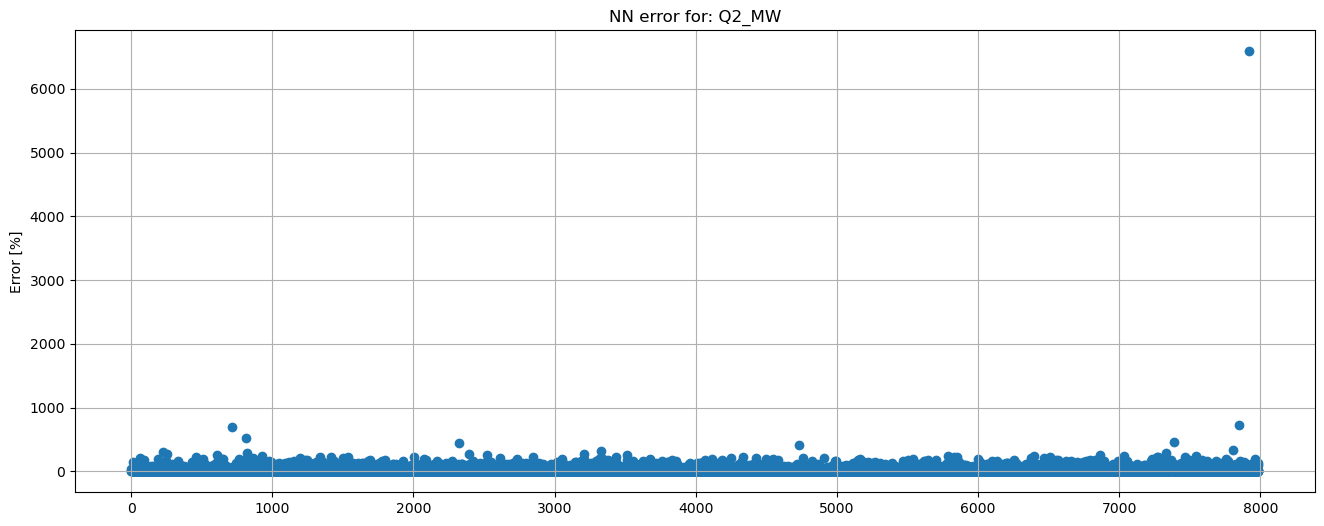

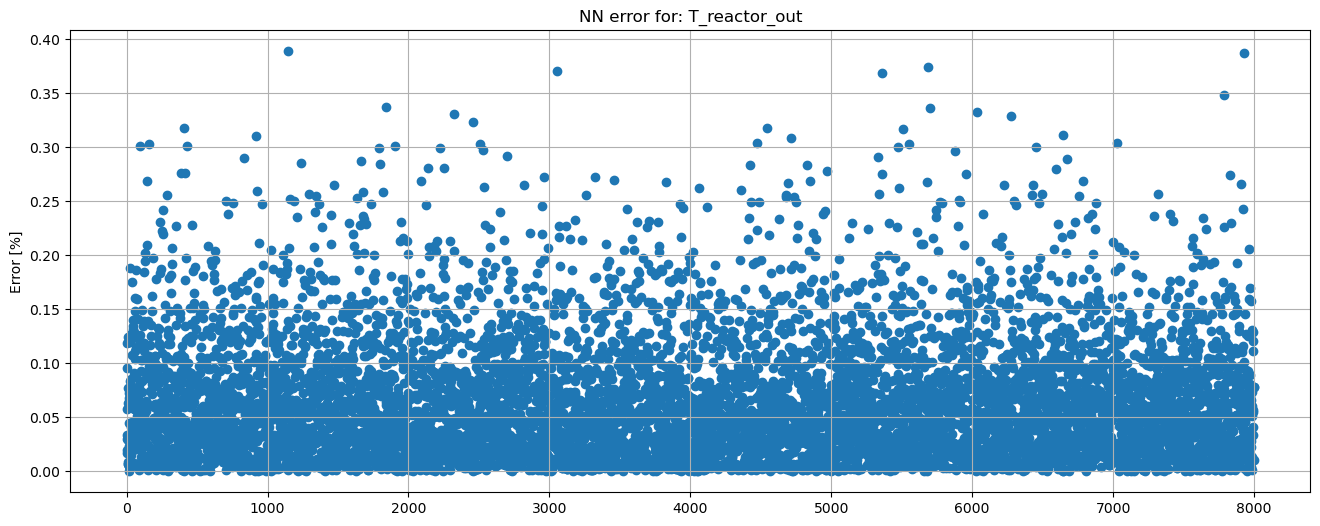

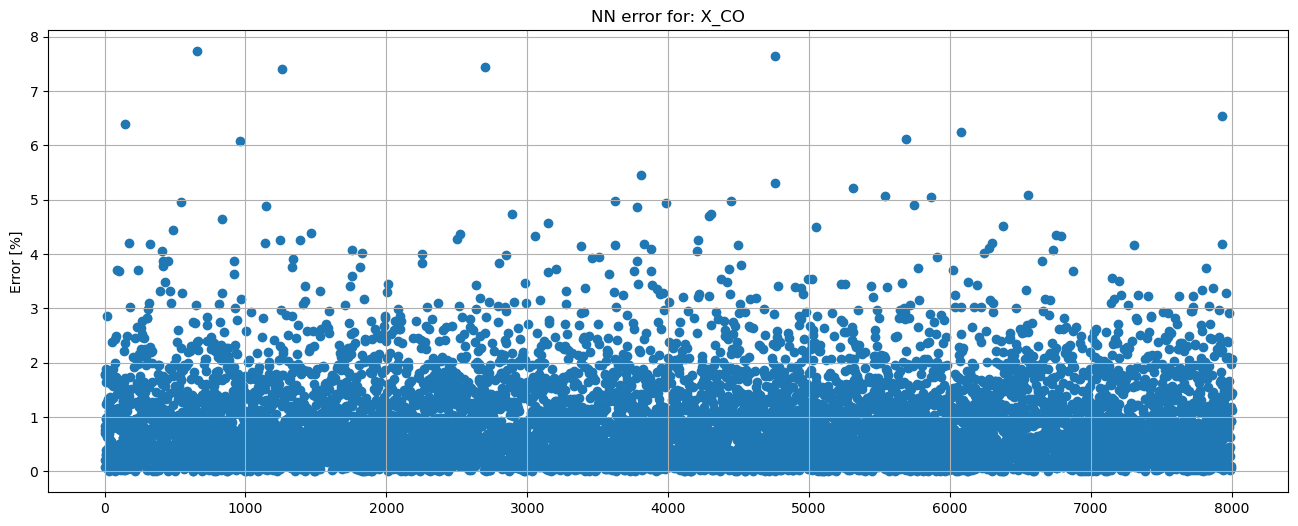

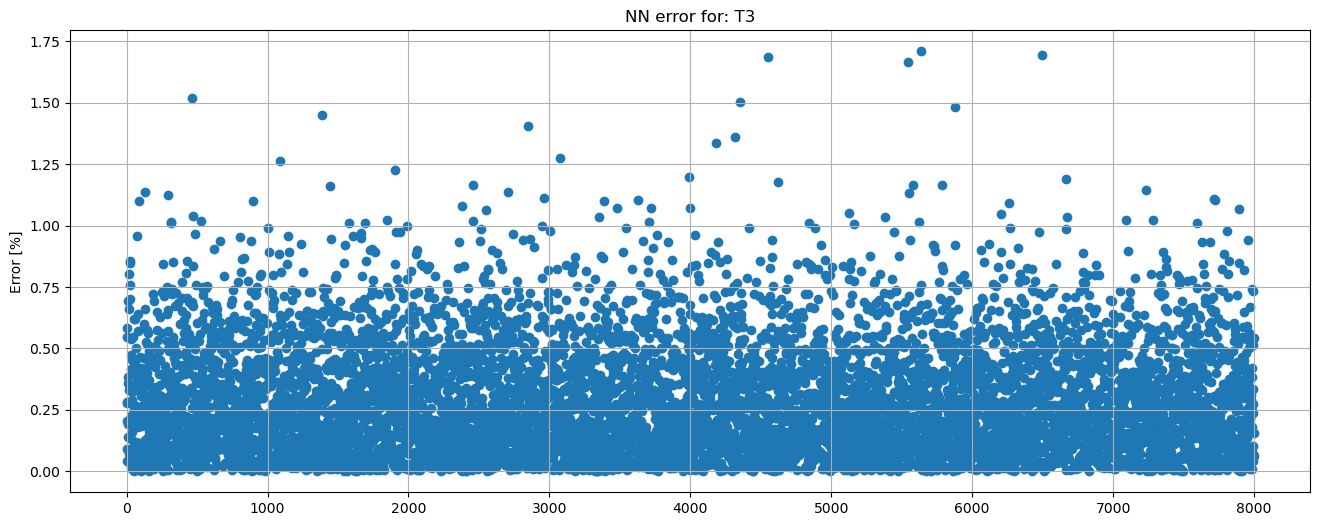

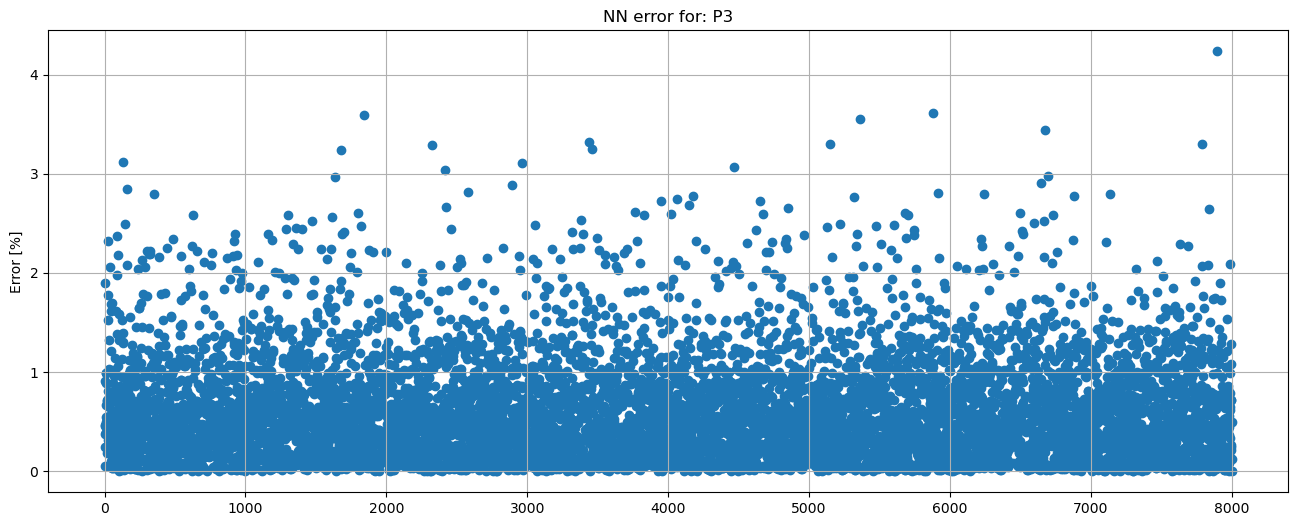

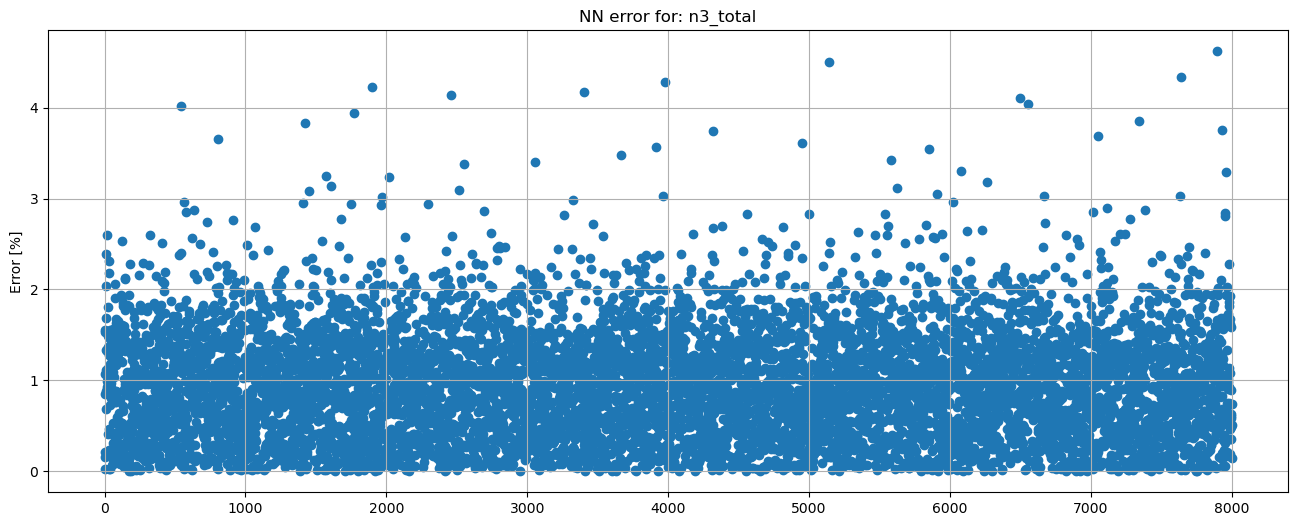

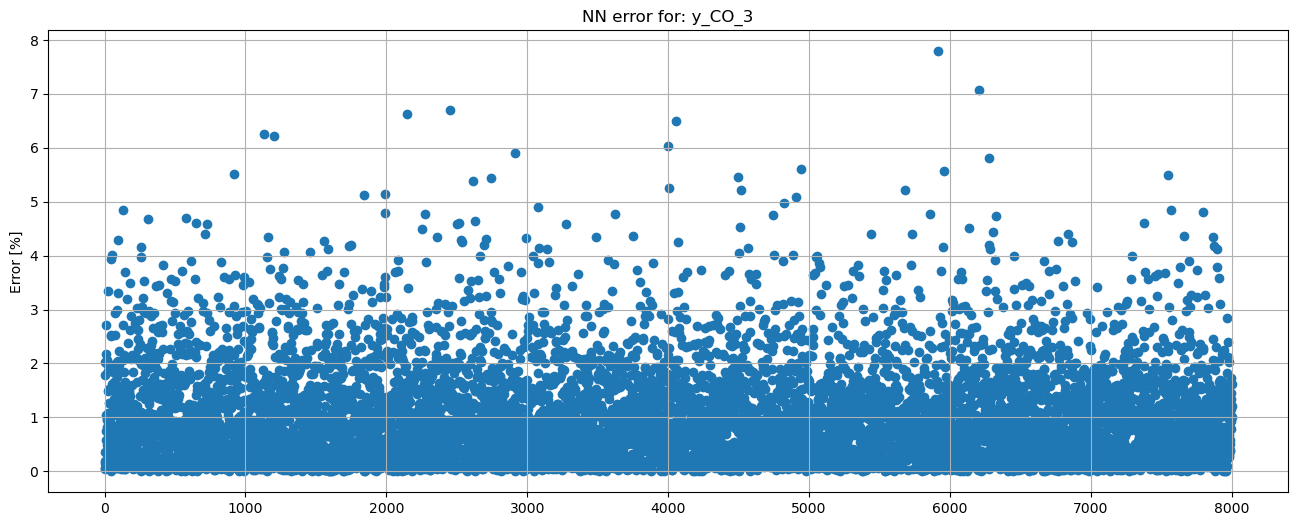

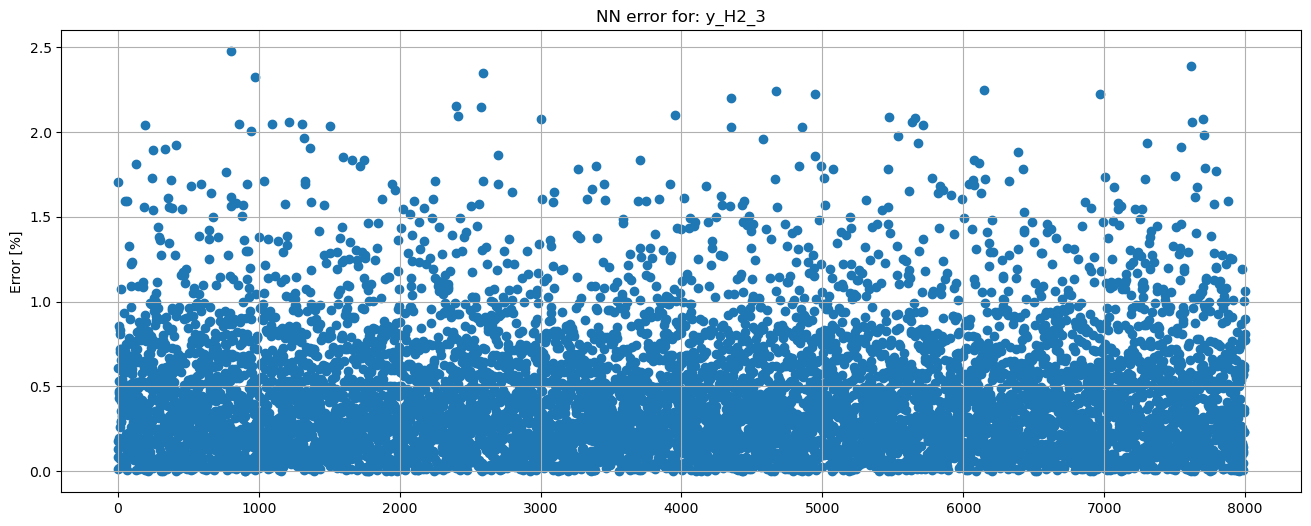

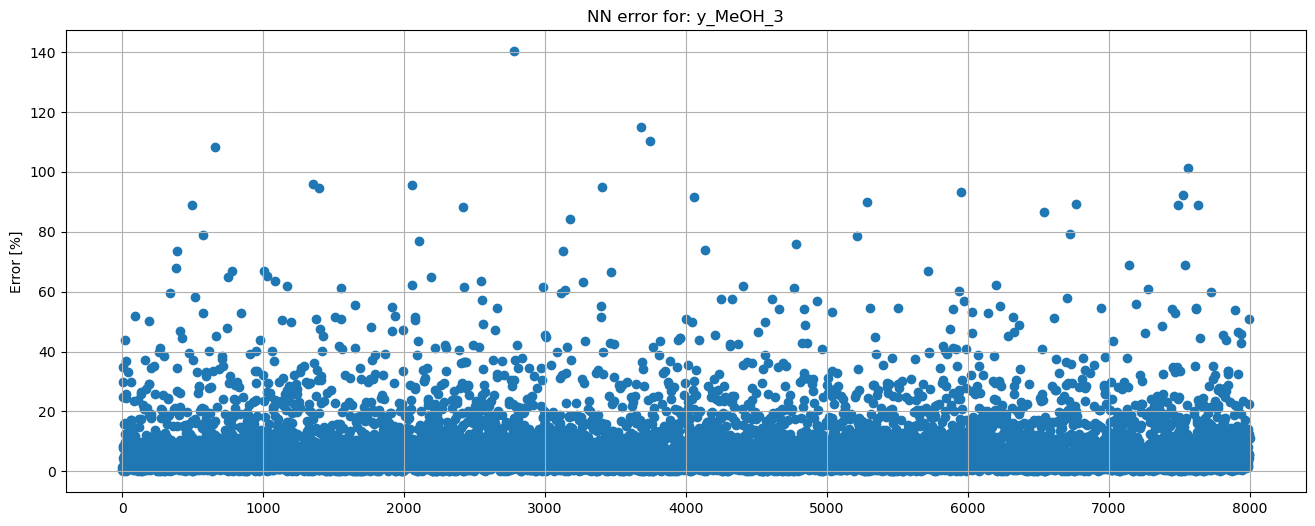

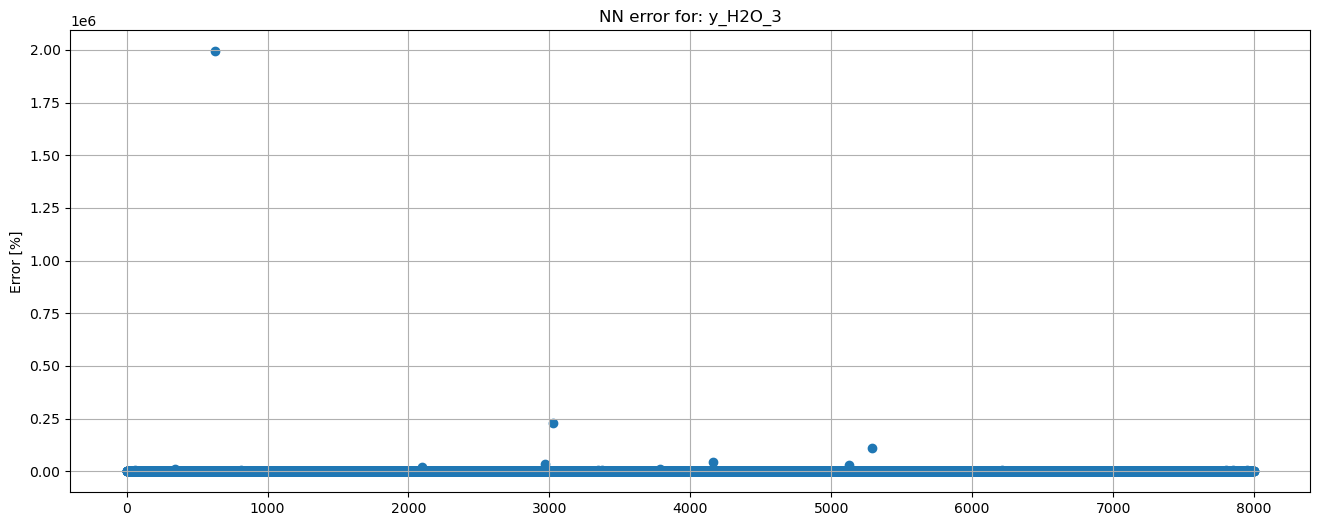

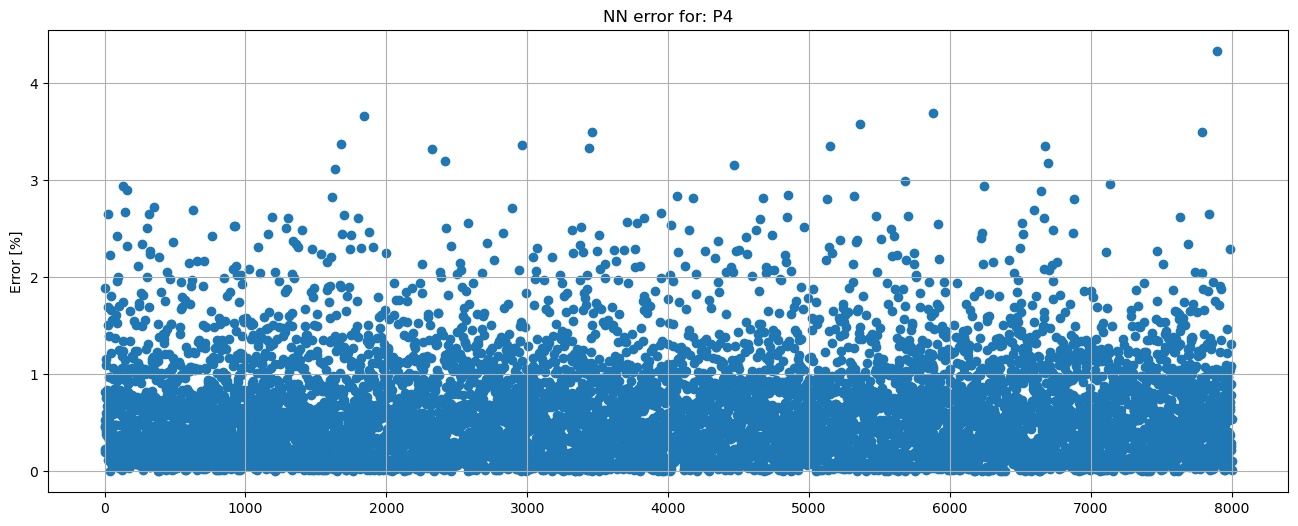

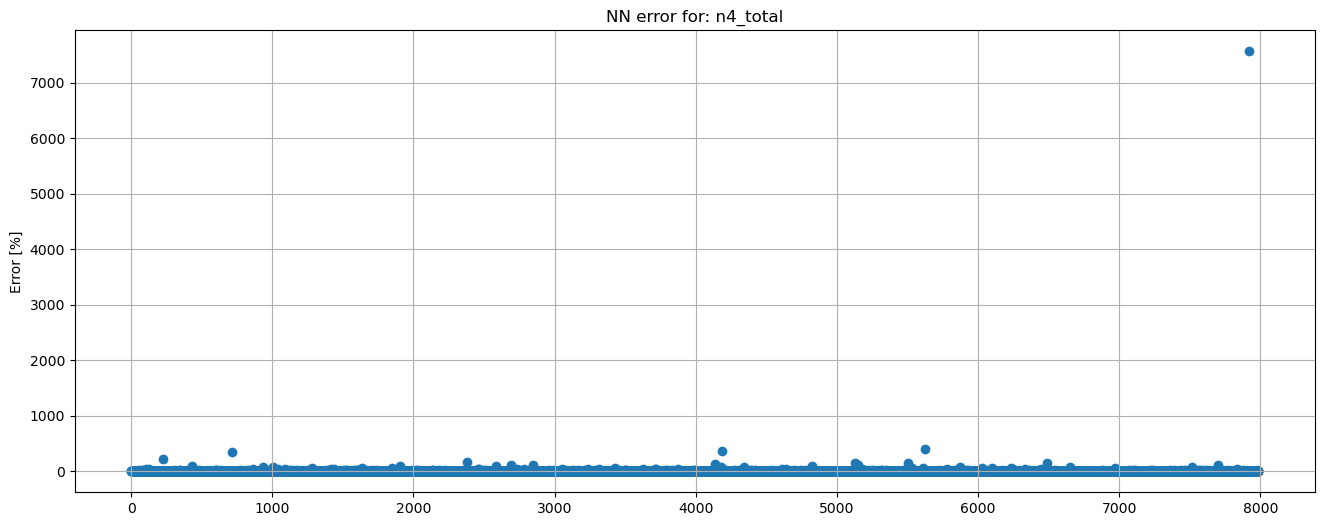

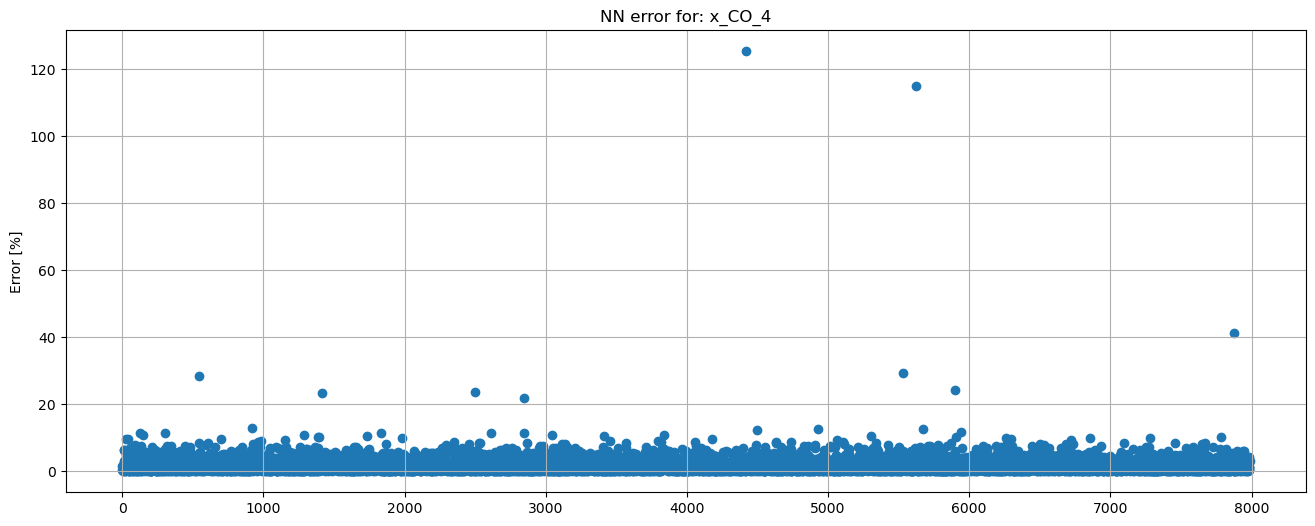

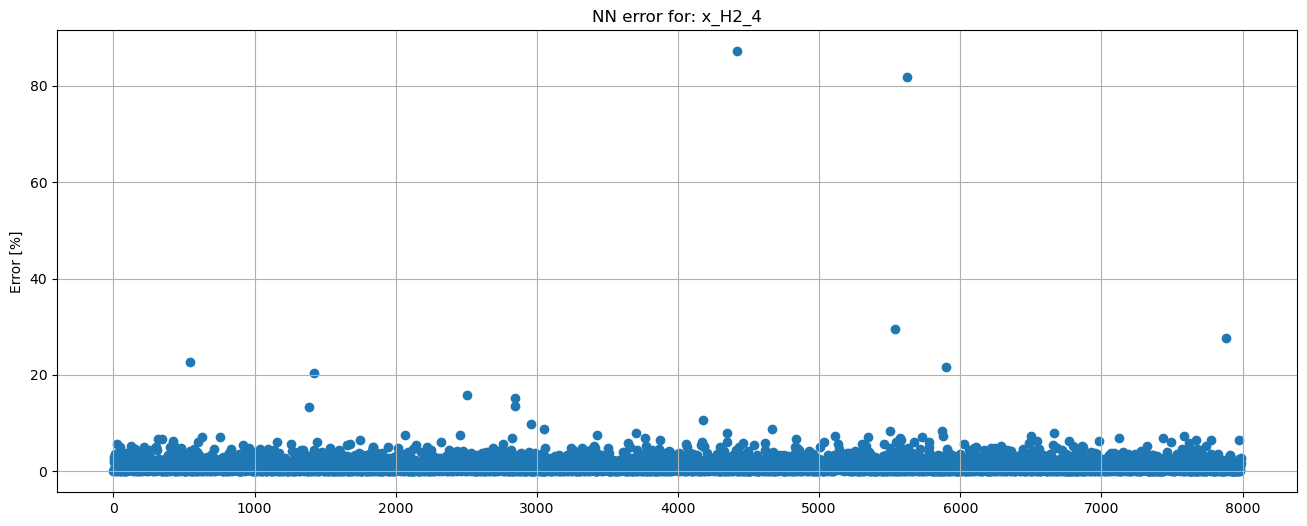

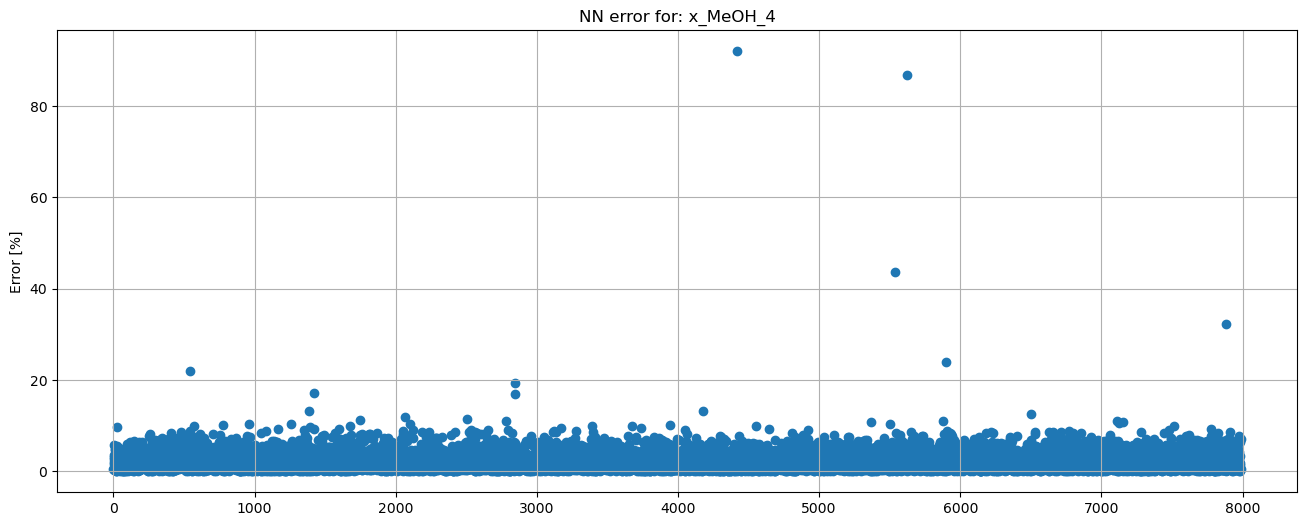

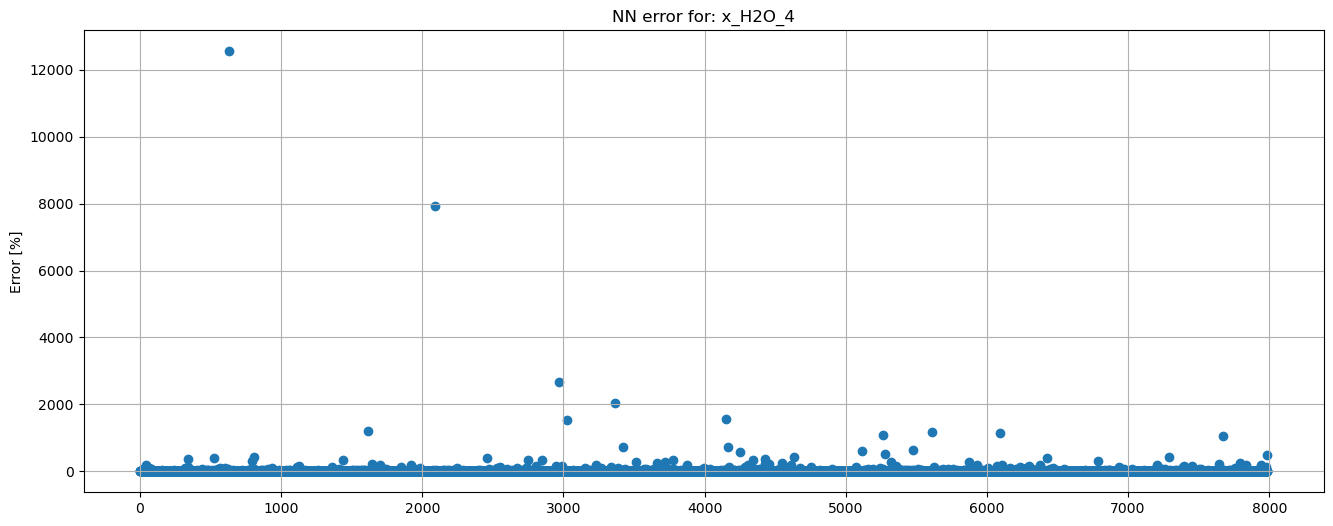

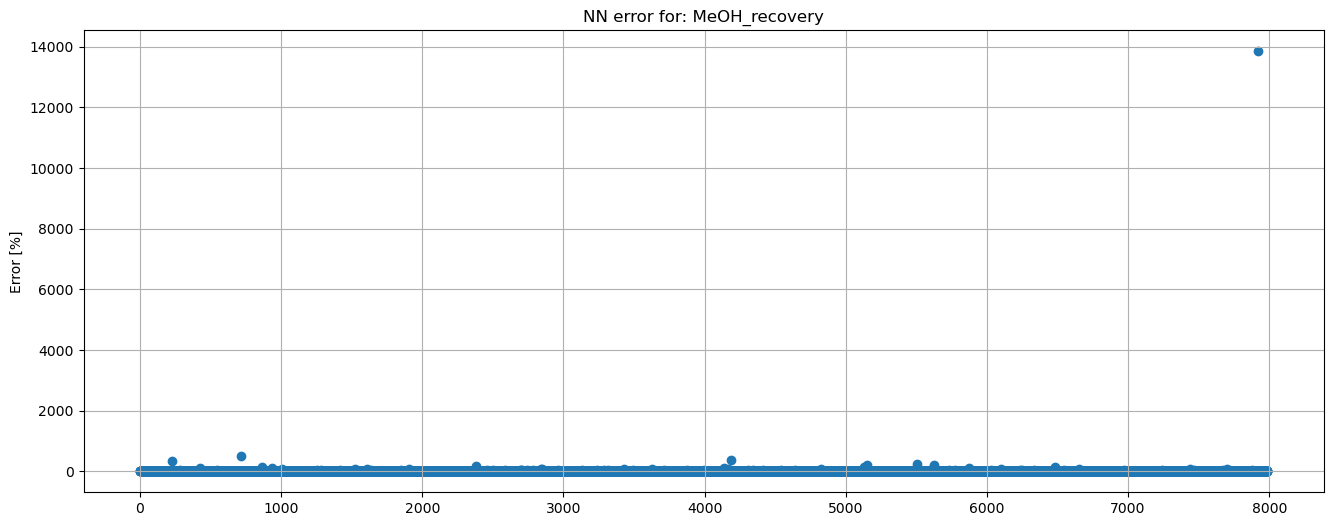

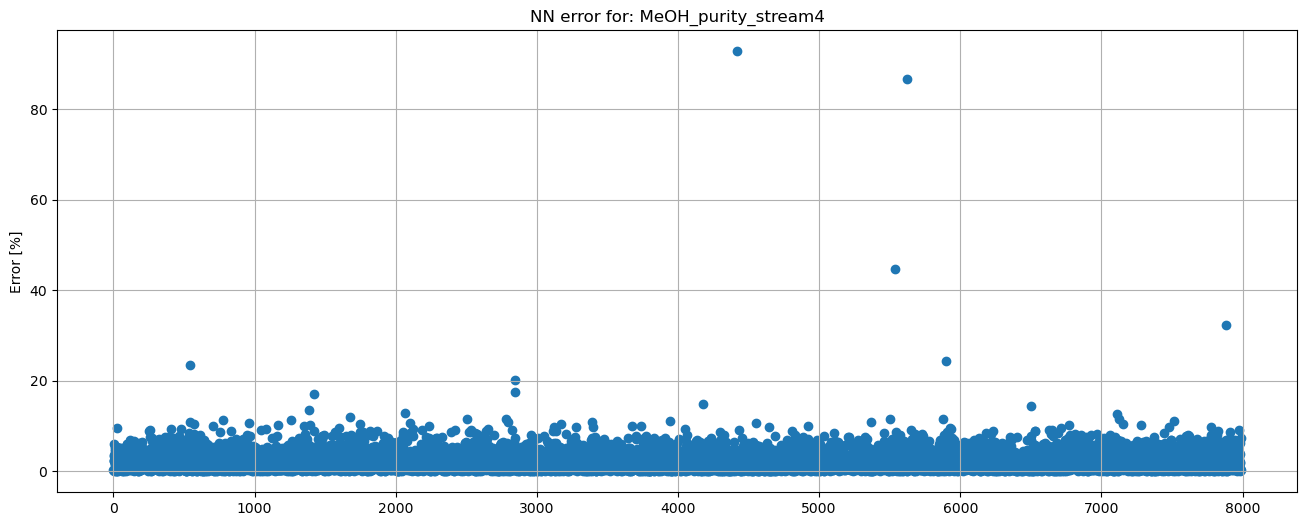

In [23]:
#print(np.average(train_error,axis=0))
for i in range(y_train.shape[1]):
    mask=y_train[:,i] !=0
    train_error=abs((model[mask,i]-y_train[mask,i])/y_train[mask,i])*100
    plt.figure(i,figsize=(16,6))
    plt.title(f'NN error for: {output_names[i]}')
    plt.scatter(range(train_error.shape[0]),train_error)
    plt.grid(True)
    plt.ylabel('Error [%]')
plt.show()